# **Project Title: How affordable is your recipe and how does it compare to restaurant trends and prices?**

by Michael Santiago


## Project objective: Is it cheaper to cook or eat out and if so by how much?

## Data overview:(Include data source, year, number of observations)

## D1. Library imports

In [ ]:
#libraries for data analysis and pre-processing, including visualization
import pandas as pd
import numpy as np
from datetime import datetime
from datetime import timedelta
import matplotlib as mpl
import seaborn as sb

#libraries for API requests, base64 is used for the Kroger API due to Auth0 authentication
import requests
import json
import base64

#prompt used to identify libraries that can analyze similar text strings "what are the best libraries to use if I wanted to compare two strings of text that may be similar and then convert both of them to a single text (i.e., one API returns the string "Brown Sugar" and other returns the string "Domino Brown Sugar", I want the code to identify this similarity and change both to "Brown Sugar" so that these fields are consistent and analysis can be performed); also any other recommended visualization libraries I should use - please provide the command to pip install these external libraries"
#libraries for matching string text among recipe names and ingredients, especially as the Tasty API returns the ingredients as a single text string with measurements and all recipes in one column
!pip install fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from difflib import SequenceMatcher

#code to mount my google drive to import the dish.csv from the Whats On the Menu export (API discontinued as of January 2025; attempted to get credentials but was able to get CSV with over 400,000 records)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##D2. Data pre-processing

In [ ]:
#see prompt 2 below for Claude assistance
#code to connect to the Tasty API
tasty_url = "https://tasty.p.rapidapi.com/recipes/list" #assign url link to a variable
tasty_headers = {
##	"x-rapidapi-key":
	"x-rapidapi-host": "tasty.p.rapidapi.com"
} #api key and server host data needed for header
tasty_param = {
    "from" : "0",
    "size" : "500",
} #API parameters to obtain the data, want to look for recipes under 30 minutes and up to 500 responses
tasty_results = requests.get(tasty_url, headers= tasty_headers, params = tasty_param).json() #method chain to store results in a variable

In [ ]:
#code to learn a little more about the data before converting to dataframe. We can see the ingredients are stored in tasty_results['results'][0]['sections'][0]['components'] as a large string. The goal to cleanse and normalize this data is to create an ingredients_df that stores the paired down ingredients and measurements in individual columns. But first want to import the rest of my data to see what columns are necessary and if I want to do anything about null values or data types
print(tasty_results.keys())
print(tasty_results['count'])
print(tasty_results['results'][0].keys())
print(tasty_results['results'][0]['name'])
print(tasty_results['results'][0]['name'])
print(tasty_results['results'][0]['price'])
print(tasty_results['results'][0]['price'])
print(len(tasty_results))
print(tasty_results['results'][0]['sections'])
print(tasty_results['results'][39]['sections'][0]['components'])

dict_keys(['count', 'results'])
10345
dict_keys(['approved_at', 'aspect_ratio', 'beauty_url', 'brand', 'brand_id', 'buzz_id', 'canonical_id', 'compilations', 'cook_time_minutes', 'country', 'created_at', 'credits', 'description', 'draft_status', 'facebook_posts', 'id', 'inspired_by_url', 'instructions', 'is_app_only', 'is_one_top', 'is_shoppable', 'is_subscriber_content', 'keywords', 'language', 'name', 'num_servings', 'nutrition', 'nutrition_visibility', 'original_video_url', 'prep_time_minutes', 'price', 'promotion', 'renditions', 'sections', 'seo_path', 'seo_title', 'servings_noun_plural', 'servings_noun_singular', 'show', 'show_id', 'slug', 'tags', 'thumbnail_alt_text', 'thumbnail_url', 'tips_and_ratings_enabled', 'topics', 'total_time_minutes', 'total_time_tier', 'updated_at', 'user_ratings', 'video_ad_content', 'video_id', 'video_url', 'yields'])
Low-Carb Avocado Chicken Salad
Low-Carb Avocado Chicken Salad
{'consumption_portion': 200, 'consumption_total': 750, 'portion': 450, 't

In [ ]:
print(tasty_results['results'][0].keys())
print(tasty_results['results'][38]['name'])
print(tasty_results['results'][39]['name'])
print(tasty_results['results'][0]['prep_time_minutes'])
print(tasty_results['results'][0]['total_time_minutes'])
print(tasty_results['results'][0]['user_ratings'])

dict_keys(['approved_at', 'aspect_ratio', 'beauty_url', 'brand', 'brand_id', 'buzz_id', 'canonical_id', 'compilations', 'cook_time_minutes', 'country', 'created_at', 'credits', 'description', 'draft_status', 'facebook_posts', 'id', 'inspired_by_url', 'instructions', 'is_app_only', 'is_one_top', 'is_shoppable', 'is_subscriber_content', 'keywords', 'language', 'name', 'num_servings', 'nutrition', 'nutrition_visibility', 'original_video_url', 'prep_time_minutes', 'price', 'promotion', 'renditions', 'sections', 'seo_path', 'seo_title', 'servings_noun_plural', 'servings_noun_singular', 'show', 'show_id', 'slug', 'tags', 'thumbnail_alt_text', 'thumbnail_url', 'tips_and_ratings_enabled', 'topics', 'total_time_minutes', 'total_time_tier', 'updated_at', 'user_ratings', 'video_ad_content', 'video_id', 'video_url', 'yields'])
Jacket Potato: The Canadian
Hearty Turkey Tacos
15
15
{'count_negative': 75, 'count_positive': 855, 'score': 0.9193548387096774}


In [ ]:
tasty_recipes = tasty_results['results'] #code to store only the recipe values and not the count

In [ ]:
tasty_recipes

[{'approved_at': 1553195044,
  'aspect_ratio': '1:1',
  'beauty_url': None,
  'brand': None,
  'brand_id': None,
  'buzz_id': None,
  'canonical_id': 'recipe:4704',
  'compilations': [{'approved_at': 1553197578,
    'aspect_ratio': '1:1',
    'beauty_url': None,
    'buzz_id': None,
    'canonical_id': 'compilation:848',
    'country': 'US',
    'created_at': 1546890391,
    'description': 'Whether you’re trying to be healthy, pulling an all-nighter, or just trying to get through the day, protein-packed snacks are your best friends. That’s because protein can give you an energy boost and help you stay fuller longer. From <a href="https://tasty.co/recipe/avocado-deviled-eggs">avocado deviled eggs</a> to <a href="https://tasty.co/recipe/cacao-chia-pudding">cacao chia pudding</a>, these snacks are full of protein-packed ingredients like Greek yogurt and almond butter, which will ensure you don’t get hangry anytime soon.',
    'draft_status': 'published',
    'facebook_posts': [],
    'id'

In [ ]:
#see prompt 3 below for how the dataframe was created
tasty_list = [] #initializing a variable with an empty list to begin storing the columns I want

# Initialize a counter for recipe_id
recipe_id = 1

for recipe in tasty_recipes: #code using the .get() method to obtain the values below associated with each key looped through (time and servings)
    name = recipe.get("name")
    total_time = recipe.get("total_time_minutes")
    prep_time = recipe.get("prep_time_minutes")
    cook_time = recipe.get("cook_time_minutes")
    servings = recipe.get("num_servings")


    ratings = recipe.get("user_ratings", {}) #code using the .get() method to obtain the values below associated with each key looped through (ratings)
    rating_score = ratings.get("score")
    rating_positive = ratings.get("count_positive")
    rating_negative = ratings.get("count_negative")


    ingredients = [] #code using the .get() method to obtain the values below associated with each key looped through (loop to obtain all ingredients in the components dictionary)
    for section in recipe.get("sections", []):
        for item in section.get("components", []):
            raw_text = item.get("raw_text")
            if raw_text:
                ingredients.append(raw_text)

    #code to add these list values to the blank list initialized earlier in this code block and rename columns/keys
    tasty_list.append({
        "recipe_id": recipe_id,  # Add the recipe_id here
        "Recipe Name": name,
        "Total Time (min)": total_time,
        "Prep Time (min)": prep_time,
        "Cook Time (min)": cook_time,
        "Servings": servings,
        "Rating Score": rating_score,
        "Positive Ratings": rating_positive,
        "Negative Ratings": rating_negative,
        "Ingredients": ingredients
    })

    # Increment the recipe_id for the next recipe
    recipe_id += 1

In [ ]:
tasty_df = pd.DataFrame(tasty_list) #code to convert the list of recipes, with the columns of interest, to a dataframe

In [ ]:
tasty_df['Ingredients']

,Ingredients
0,"[⅔ cup plain Greek yogurt, 1 tablespoon lime j..."
1,"[16 ounces cream cheese, softened, ½ cup sugar..."
2,"[1 tablespoon unsalted butter, 10 anchovy file..."
3,"[4 eggs, 2 cups granulated sugar, 1 cup vegeta..."
4,"[2 large egg whites, 4 tablespoons plus 1/2 te..."
5,"[3 ounces finely chopped pecans (about 1 cup),..."
6,"[3 cups whole milk ricotta, 3½ cups shredded l..."
7,"[1 cup shredded mozzarella cheese, 1 egg yolk]"
8,"[2 tablespoons unsalted butter, 1 pound spicy ..."
9,"[1 stick butter, ½ cup flour, 8 cups milk, 2 t..."


In [ ]:
tasty_df.columns

Index(['recipe_id', 'Recipe Name', 'Total Time (min)', 'Prep Time (min)',
       'Cook Time (min)', 'Servings', 'Rating Score', 'Positive Ratings',
       'Negative Ratings', 'Ingredients'],
      dtype='object')

In [ ]:
#code to subset tasty_df
tasty_df_ingredients = tasty_df.copy()
tasty_df_ingredients.drop(columns=['Total Time (min)', 'Prep Time (min)', 'Cook Time (min)',
       'Servings', 'Rating Score', 'Positive Ratings', 'Negative Ratings'], inplace=True)
tasty_df_ingredients.to_excel('Ingredients_export_current.xlsx', index=False) #code to export the ingredients so that I may use them in the prompts below to obtain the list of ingredients I will need to search for in the Kroger API call, using the parameters provided by the API.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#prompt 6 & 7, using the most recent ingredients from the API called:
kroger_search_terms = [
    # Recipe ID 1
    ["greek yogurt", "lime juice", "pepper", "chili powder", "avocado", "chicken breast", "celery", "red onion", "salt", "bread", "cilantro"],

    # Recipe ID 2
    ["cream cheese", "sugar", "sour cream", "vanilla extract", "eggs", "butter", "brown sugar", "cinnamon", "cinnamon rolls"],

    # Recipe ID 3
    ["eggs", "sugar", "vegetable oil", "vanilla extract", "flour", "baking soda", "baking powder", "sour cream", "blueberries"],

    # Recipe ID 4
    ["butter", "anchovy", "bread crumbs", "parmesan cheese", "olive oil", "garlic", "red pepper flakes", "cherry tomatoes", "salt", "white wine", "spaghetti", "lemon zest"],

    # Recipe ID 5
    ["egg whites", "sugar", "flour", "powdered sugar", "vanilla extract", "food coloring", "buttercream"],

    # Recipe ID 6
    ["pecans", "coconut oil", "brown sugar", "sugar", "non-dairy milk", "vanilla extract", "flour", "baking soda", "salt", "dark chocolate", "chocolate chunks"],

    # Recipe ID 7
    ["ricotta", "mozzarella cheese", "parmesan cheese", "eggs", "parsley", "salt", "olive oil", "onion", "ground beef", "garlic", "spice blend", "marinara sauce", "cooking spray", "lasagna noodles"],

    # Recipe ID 8
    ["butter", "italian sausage", "salt", "onion", "jalapeno", "garlic", "tomato paste", "spice blend", "penne pasta", "red bell pepper", "green bell pepper", "mushrooms", "tomatoes", "chicken stock", "cream cheese", "scallions"],

    # Recipe ID 9
    ["mozzarella cheese", "egg yolk", "pasta"],

    # Recipe ID 10
    ["sweet potatoes", "cooking spray", "salt", "maple syrup", "bacon bits", "marshmallow fluff", "sprinkles"],

    # Recipe ID 11
    ["butter", "flour", "milk", "salt", "pepper", "nutmeg", "olive oil", "onion", "carrots", "celery", "ground beef", "tomato sauce", "tomato paste", "chicken stock", "lasagna noodles", "parmesan cheese", "chives"],

    # Recipe ID 12
    ["orange zest", "orange juice", "ginger juice", "garlic", "soy sauce", "sesame oil", "mirin", "apple cider vinegar", "chile", "sugar", "olive oil", "salt", "octopus", "cilantro", "shallot", "red wine vinegar", "peppercorns", "cream cheese", "mayonnaise", "old bay seasoning", "garlic powder", "horseradish", "lemon zest", "lemon juice", "worcestershire sauce", "crab meat", "chives", "oysters", "ice", "lettuce", "poke salad", "lox", "shrimp", "cocktail sauce", "horseradish", "seaweed salad", "bread", "crackers", "cucumber", "crab claws", "orange", "pickled vegetables", "capers", "lemons"],

    # Recipe ID 13
    ["spice blend", "salt", "pepper", "shrimp", "water", "grits", "cheddar cheese", "butter", "bacon", "garlic", "white wine", "chicken stock", "chives"],

    # Recipe ID 14
    ["garlic", "olive oil", "salt", "half-and-half", "heavy cream", "cream cheese", "gruyere cheese", "cheddar cheese", "parmesan cheese", "potatoes", "thyme", "pepper", "chives"],

    # Recipe ID 15
    ["butternut squash", "achiote powder", "chile powder", "garlic powder", "onion powder", "coriander", "thyme", "cumin", "salt", "pepper", "cayenne", "apple cider vinegar", "orange juice", "olive oil", "pineapple", "corn tortillas", "onion", "cilantro", "avocado", "limes"],

    # Recipe ID 16
    ["garlic", "salt", "pepper", "olive oil", "lemon juice", "chicken cutlets", "quinoa and rice", "zucchini", "parsley", "lemon zest", "oregano", "coriander", "paprika", "eggs", "breadcrumbs", "feta cheese", "tomatoes", "olives"],

    # Recipe ID 17
    ["olive oil", "garlic", "red pepper flakes", "spice blend", "tomato paste", "tomatoes", "salt", "bread", "heavy cream", "parmesan cheese", "onion", "pepper", "ground pork", "ground beef", "spaghetti", "basil"],

    # Recipe ID 18
    ["cooking oil", "onion", "sweet potato", "apple", "carrot", "garlic", "lentils", "tomatoes", "vegetable broth", "curry powder", "bay leaf", "cinnamon stick", "salt", "pepper"],

    # Recipe ID 19
    ["russet potatoes", "cooking spray", "salt", "milk", "bacon", "queso", "green onion"],

    # Recipe ID 20
    ["spice blend", "salt", "pepper", "buttermilk", "chicken", "flour", "canola oil"],

    # Recipe ID 21
    ["sugar", "water", "ginger", "orange juice", "prosecco", "orange liqueur", "club soda", "orange"],

    # Recipe ID 22
    ["hummus", "mustard", "garlic", "nutritional yeast", "capers", "lemon juice", "miso", "olive oil", "salt", "pepper", "mixed greens"],

    # Recipe ID 23
    ["spice blend", "salt", "pepper", "chicken thighs", "vegetable oil", "butter", "onion", "red bell pepper", "garlic", "rice", "chicken stock", "lemon", "basil"],

    # Recipe ID 24
    ["sweet potatoes", "cooking spray", "salt", "maple syrup", "pumpkin brittle", "ice cream", "sprinkles"],

    # Recipe ID 25
    ["russet potatoes", "cooking spray", "salt", "milk", "bacon", "queso", "potato chips"],

    # Recipe ID 26
    ["salt", "spice blend", "pepper", "lamb chops", "canola oil", "garlic", "orange zest", "orange juice", "mint", "yogurt", "chicken broth", "butter", "couscous", "dates", "olive oil", "parsley", "chives", "pine nuts"],

    # Recipe ID 27
    ["milk", "ice cream", "chocolate candy", "sprinkles", "caramel sauce"],

    # Recipe ID 28
    ["milk", "ice cream", "chocolate candy", "marshmallows", "caramel sauce"],

    # Recipe ID 29
    ["sesame oil", "mirin", "spice blend", "salt", "tofu", "sweet potatoes", "broccoli", "quinoa", "purple cabbage", "cucumber", "avocado", "peanuts", "cilantro", "mint"],

    # Recipe ID 30
    ["water", "tea bag", "lavender buds", "honey", "whiskey", "lemon"],

    # Recipe ID 31
    ["milk", "chocolate chips", "cinnamon", "marshmallows", "chocolate"],

    # Recipe ID 32
    ["chicken wings", "salt", "pepper", "canola oil", "butter", "lime juice", "garlic", "brown sugar", "honey", "spice blend", "cornstarch", "water", "cilantro", "lime zest"],

    # Recipe ID 33
    ["chocolate ice cream", "pound cake", "chocolate", "sprinkles", "ice cream cones", "white icing", "shortbread cookies", "pretzels", "vanilla ice cream", "strawberry ice cream", "mint chocolate chip ice cream", "toppings"],

    # Recipe ID 34
    ["olive oil", "garlic", "spice blend", "tomatoes", "white wine", "bay leaves", "salt", "pepper", "fish", "basil"],

    # Recipe ID 35
    ["sweet potatoes", "cooking spray", "salt", "maple syrup", "bacon bits", "ice cream", "chocolate chips"],

    # Recipe ID 36
    ["graham crackers", "butter", "vanilla pudding mix", "heavy cream", "chocolate candy", "whipped cream"],

    # Recipe ID 37
    ["russet potatoes", "cooking spray", "salt", "milk", "chickpeas", "queso", "green onion"],

    # Recipe ID 38
    ["tomatoes", "olive oil", "onion", "garlic", "spice blend", "salt", "pepper", "vegetable stock", "rice", "balsamic vinegar", "basil", "bread", "butter", "cheddar cheese", "havarti cheese"],

    # Recipe ID 39
    ["flour", "sugar", "baking powder", "baking soda", "salt", "milk", "butter", "vanilla", "egg", "pumpkin puree"],

    # Recipe ID 40
    ["cooking spray", "waffle mix", "milk", "egg", "vegetable oil", "flour", "sugar", "baking powder", "baking soda", "salt", "butter", "buttermilk", "maple syrup", "whipped cream", "berries", "sprinkles"]
]

In [ ]:
#see prompt 2, 4, 7, 8 below for Claude assistance. Needed a code that will a.) parse through the results and pull prices for products. In first go-around, there were null values as the price did not exist at the given Kroger location; therefore needed coded to iterate and pull prices from multiple Kroger locations. I also needed a list of basic ingredients that can be used in the Kroger parameters as the recipe ingredients from the Tasty API was one large text string with all of the ingredients.
#code to connect to the Kroger API

import base64
import requests
import json
import pandas as pd
import time

kroger_id =
kroger_credentials = f"{kroger_id}:{kroger_secret}"
#Kroger API requires the client ID and client secret to be encoded in Base64 format for authentication
encoded_credentials = base64.b64encode(kroger_credentials.encode()).decode()

token_url = "https://api.kroger.com/v1/connect/oauth2/token" #url to endpoint to get access token from Kroger
token_headers = {
    "Content-Type": "application/x-www-form-urlencoded",
    "Authorization": f"Basic {encoded_credentials}"
} #headers for token request
token_data = {"grant_type": "client_credentials", "scope": "product.compact"} #request of access to product data

# Make the token request once
token_response = requests.post(token_url, headers=token_headers, data=token_data).json()
print("Token response:", token_response)

all_results = [] #list to store the price of each item from each Kroger location in the location id list

# Check if authentication was successful before proceeding
if 'access_token' in token_response:
    access_token = token_response['access_token']

    kroger_url = "https://api.kroger.com/v1/products" #assign url link to a variable
    kroger_headers = {
        "Accept": "application/json",
        "Authorization": f"Bearer {access_token}"
    }
   # Store location IDs for different regions
    # These are sample location IDs for major Kroger markets, used to iterate through the API. The parameter will be the list of locations, iterated through if a price of the product is not found
    location_ids = [
        "02100374",  # Ohio location
        "02600845",  # Tennessee location
        "02400522",  # Georgia location
        "02900482",  # Texas location
        "02500356"   # Indiana location
    ]

    # Loop through each recipe; see prompt 7 & 8
    for recipe_idx, ingredients in enumerate(kroger_search_terms, 1):
        print(f"\nProcessing Recipe {recipe_idx}/{len(kroger_search_terms)}")
        recipe_results = []

        # Loop through each ingredient in the recipe
        for ingredient_idx, ingredient in enumerate(ingredients, 1):
            print(f"  Searching for: {ingredient}")
            ingredient_results = []

            # Try each location ID to find prices
            for location_id in location_ids:
                print(f"    Checking location ID: {location_id}")

                # Set up request parameters
                kroger_params = {
                    "filter.term": ingredient,
                    "filter.locationId": location_id,
                    "filter.limit": "3"  # Limit to 3 results per location for efficiency
                }

                # Make the API request
                try:
                    response = requests.get(kroger_url, headers=kroger_headers, params=kroger_params)
                    response_data = response.json()

                    # Check if we got valid data with prices
                    if 'data' in response_data and len(response_data['data']) > 0:
                        products_with_prices = 0

                        # Process each product returned
                        for product in response_data['data']:
                            product_info = {
                                'recipe_id': recipe_idx,
                                'ingredient': ingredient,
                                'product_id': product.get('productId', ''),
                                'description': product.get('description', ''),
                                'brand': product.get('brand', ''),
                                'location_id': location_id
                            }

                            # Extract price information if available
                            has_price = False
                            if 'items' in product and len(product['items']) > 0:
                                item = product['items'][0]
                                if 'price' in item:
                                    product_info['regular_price'] = item['price'].get('regular', None)
                                    product_info['promo_price'] = item['price'].get('promo', None)
                                    if item['price'].get('regular', None) is not None:
                                        has_price = True
                                        products_with_prices += 1

                                # Extract size information if available
                                product_info['size'] = item.get('size', '')

                            # Add to results if it has a price
                            if has_price:
                                ingredient_results.append(product_info)
                                all_results.append(product_info)

                        print(f"      Found {products_with_prices} products with prices")

                        # If we found at least 2 products with prices, we can move to the next ingredient
                        if products_with_prices >= 2:
                            break
                    else:
                        print(f"      No products found or error in API response")

                except Exception as e:
                    print(f"      Error: {str(e)}")

                # Add a small delay to avoid hitting rate limits
                time.sleep(0.5)

            # Add ingredient results to recipe results
            recipe_results.extend(ingredient_results)

        # Print recipe results summary
        print(f"  Recipe {recipe_idx} results: {len(recipe_results)} products found")

Token response: {'expires_in': 1800, 'access_token': 'eyJhbGciOiJSUzI1NiIsImprdSI6Imh0dHBzOi8vYXBpLmtyb2dlci5jb20vdjEvLndlbGwta25vd24vandrcy5qc29uIiwia2lkIjoiWjRGZDNtc2tJSDg4aXJ0N0xCNWM2Zz09IiwidHlwIjoiSldUIn0.eyJhdWQiOiJueXVwcm9qZWN0ZGF0YWFuYWx5c2lzZm9vZC0yNDMyNjEyNDMwMzQyNDc4NmU3MDc0NmY1NzY0NmM2ZDMwNzg1YTMzNmY0NDM5NTQ0MTQyNGU0ZDY1NGQ1MTQ1NTk0NTZmNDk0MjQxNmI1MzQxNTAzOTMzNDQ2NjY4NTc0MTYyNDczMjU2NzE2ZTQ5NjE2MTM4NGY5MTExMDMwNDczNDg1NDYxMTU1IiwiZXhwIjoxNzQ2NDkyOTQ2LCJpYXQiOjE3NDY0OTExNDEsImlzcyI6ImFwaS5rcm9nZXIuY29tIiwic3ViIjoiOTE2MmRjM2MtNjZjZS01OTkwLWFiNzItNmU3NzMyNjg5ZGNjIiwic2NvcGUiOiJwcm9kdWN0LmNvbXBhY3QiLCJhdXRoQXQiOjE3NDY0OTExNDY0NDUzMjIyNTUsImF6cCI6Im55dXByb2plY3RkYXRhYW5hbHlzaXNmb29kLTI0MzI2MTI0MzAzNDI0Nzg2ZTcwNzQ2ZjU3NjQ2YzZkMzA3ODVhMzM2ZjQ0Mzk1NDQxNDI0ZTRkNjU0ZDUxNDU1OTQ1NmY0OTQyNDE2YjUzNDE1MDM5MzM0NDY2Njg1NzQxNjI0NzMyNTY3MTZlNDk2MTYxMzg0ZjkxMTEwMzA0NzM0ODU0NjExNTUifQ.FxWvdv9gu4YW263ZlltWxuVvzRsTsDqlGcNTJyYFW_grTez-dJj5loAB37m6hZhpn4dOrGsr49uZ-BVwrzHZSZ7zK0UThcwfXhtcAx1LoblsEet

In [ ]:
# Gemini prompt: #code to learn a little more about the data in the all_results list before converting to dataframe

# Print the keys of the first element in all_results to understand its structure
print(all_results[0].keys())

# Print the first 5 elements of all_results to inspect the data
for i in range(min(5, len(all_results))):
  print(all_results[i])

# Check data types of key fields
print(type(all_results[0]['recipe_id']))


dict_keys(['recipe_id', 'ingredient', 'product_id', 'description', 'brand', 'location_id', 'regular_price', 'promo_price', 'size'])
{'recipe_id': 1, 'ingredient': 'greek yogurt', 'product_id': '0001111010760', 'description': 'Simple Truth Organic® Plain Nonfat Greek Yogurt Tub', 'brand': 'Simple Truth Organic', 'location_id': '02600845', 'regular_price': 4.99, 'promo_price': 0, 'size': '32 oz'}
{'recipe_id': 1, 'ingredient': 'greek yogurt', 'product_id': '0001111010717', 'description': 'Kroger® Plain Nonfat Greek Yogurt Tub', 'brand': 'Kroger', 'location_id': '02600845', 'regular_price': 4.29, 'promo_price': 3.99, 'size': '32 oz'}
{'recipe_id': 1, 'ingredient': 'greek yogurt', 'product_id': '0001111050481', 'description': 'Kroger® Plain Nonfat Greek Yogurt Cup', 'brand': 'Kroger', 'location_id': '02600845', 'regular_price': 0.79, 'promo_price': 0, 'size': '5.3 oz'}
{'recipe_id': 1, 'ingredient': 'lime juice', 'product_id': '0001111072822', 'description': 'Kroger® Lime Juice', 'brand': 

In [ ]:
kroger_df = pd.DataFrame(all_results)

In [ ]:
import pandas as pd
import re

#See prompt 9. For data cleansing and analysis purposes, the tasty_df['Ingredients'] column contained all of the ingredients, but as one single string. A library (re) was required to ensure that I can: Seperate ingredients from one another and add a column for each ingredient, and create a corresponding measurement column per ingredient to multiple by Kroger product price within the Kroger dataframe.

# Step 1: Parse the ingredients strings into separate columns
ingredients_df = pd.DataFrame()  # Create an empty DataFrame to store results

# Loop through each recipe
for recipe_idx, ingredients_list in enumerate(kroger_search_terms, 1):
    # Create a dictionary to hold this recipe's data
    recipe_data = {'recipe_id': recipe_idx}

    # Process each ingredient in the recipe
    for ing_idx, ingredient in enumerate(ingredients_list, 1):
        recipe_data[f'Ingredient_{ing_idx}'] = ingredient

    # Add this recipe to our results
    ingredients_df = pd.concat([ingredients_df, pd.DataFrame([recipe_data])], ignore_index=True)

# Step 2: Add the Kroger product info, specificall the price of products
# Use the kroger_df directly

# Create a simple lookup dictionary for product prices
ingredient_prices = {}

# Populate the ingredient_prices dictionary from kroger_df, to be used in computing the total price of the recipe
for _, row in kroger_df.iterrows():
    ingredient = row['ingredient']
    price = row['regular_price']
    if price is not None:  # Only store if we have a price
        # If we already have a price for this ingredient, average them as we pulled the price from multiple Kroger locations
        if ingredient in ingredient_prices:
            ingredient_prices[ingredient] = (ingredient_prices[ingredient] + price) / 2
        else:
            ingredient_prices[ingredient] = price

# Add price columns to the ingredients DataFrame
for recipe_idx, row in ingredients_df.iterrows():
    for col in row.index:
        if col.startswith('Ingredient_'):
            ingredient = row[col]
            price_col = col.replace('Ingredient_', 'Price_')

            # Get price if available
            if ingredient in ingredient_prices:
                ingredients_df.at[recipe_idx, price_col] = ingredient_prices[ingredient]
            else:
                ingredients_df.at[recipe_idx, price_col] = None

# Step 3: Parse the original ingredient strings to extract measurements
# Used the raw ingredient strings provided within prompt 9

raw_ingredients = []
# Define your raw ingredient data directly here
raw_data = """Ingredients
['⅔ cup plain Greek yogurt', '1 tablespoon lime juice', 'Pepper, to taste', '⅛ teaspoon chili powder', '1 avocado, cubed, divided', '2 chicken breasts, cooked and shredded', '1 celery stalk, diced', '2 tablespoons diced red onion', 'Kosher salt, to taste', 'Low-carb bread, for serving, optional', 'Fresh cilantro leaves, for garnish']"""

# Split into lines
lines = raw_data.strip().split('\n')

# Skip header line
if lines[0].strip() == 'Ingredients':
    lines = lines[1:]

# Process each line (recipe)
for line in lines:
    if line.startswith('['):
        # Remove brackets and split by commas with quotes
        ingredients = re.findall(r"'([^']*)'", line)
        raw_ingredients.append(ingredients)

# Now add measurement columns
for recipe_idx, ingredients in enumerate(raw_ingredients):
    if recipe_idx < len(ingredients_df):  # Make sure we have a matching row
        for ing_idx, ingredient_str in enumerate(ingredients, 1):
            # Simple regex to extract measurements
            measurement_match = re.search(r'^([\d\s\/\.\-]+\s*(?:cup|tablespoon|teaspoon|tsp|tbsp|oz|ounce|pound|lb|g|ml|inch|can|jar|clove|head|package)s?|to taste)',
                                         ingredient_str, re.IGNORECASE)

            if measurement_match:
                measurement = measurement_match.group(0).strip()
                ingredients_df.at[recipe_idx, f'Measurement_{ing_idx}'] = measurement

# Step 4: Calculate the total recipe cost
ingredients_df['Total_Recipe_Cost'] = 0 #initialize with a value of zero and calculte the cost using the below nested for loops

for recipe_idx, row in ingredients_df.iterrows():
    total_cost = 0
    for col in row.index:
        if col.startswith('Price_'):
            if pd.notna(row[col]):  # Only add if the price exists
                total_cost += row[col]

    ingredients_df.at[recipe_idx, 'Total_Recipe_Cost'] = total_cost

# Print summary
print(f"Total recipes processed: {len(ingredients_df)}")
print(f"Recipes with price data: {sum(ingredients_df['Total_Recipe_Cost'] > 0)}")
print("\nSample of the ingredients data:")
print(ingredients_df.head())

Total recipes processed: 40
Recipes with price data: 40

Sample of the ingredients data:
   recipe_id  Ingredient_1 Ingredient_2   Ingredient_3     Ingredient_4  \
0          1  greek yogurt   lime juice         pepper     chili powder   
1          2  cream cheese        sugar     sour cream  vanilla extract   
2          3          eggs        sugar  vegetable oil  vanilla extract   
3          4        butter      anchovy   bread crumbs  parmesan cheese   
4          5    egg whites        sugar          flour   powdered sugar   

      Ingredient_5    Ingredient_6       Ingredient_7     Ingredient_8  \
0          avocado  chicken breast             celery        red onion   
1             eggs          butter        brown sugar         cinnamon   
2            flour     baking soda      baking powder       sour cream   
3        olive oil          garlic  red pepper flakes  cherry tomatoes   
4  vanilla extract   food coloring        buttercream              NaN   

     Ingredient

<ipython-input-157-d35f0a5bf7f1>:95: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.03126621791294' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



In [ ]:
ingredients_df.head(10) #there will be NaNs as not every recipe will have the same number of ingredients and need ingredient IDs to multiply by measurement amounts. Nothing needed here, the analysis_df will include the original tasty_dfs ingredient column; this dataframe was used for calculation purposes and the total_recipe_cost will be extracted, per recipe ID, and brought into the analysis_df

,recipe_id,Ingredient_1,Ingredient_2,Ingredient_3,Ingredient_4,Ingredient_5,Ingredient_6,Ingredient_7,Ingredient_8,Ingredient_9,...,Price_38,Price_39,Price_40,Price_41,Price_42,Price_43,Price_44,Measurement_2,Measurement_8,Total_Recipe_Cost
0,1,greek yogurt,lime juice,pepper,chili powder,avocado,chicken breast,celery,red onion,salt,...,None,None,None,None,None,None,None,1 tablespoon,2 tablespoons,30.031266
1,2,cream cheese,sugar,sour cream,vanilla extract,eggs,butter,brown sugar,cinnamon,cinnamon rolls,...,None,None,None,None,None,None,None,NaN,NaN,33.896533
2,3,eggs,sugar,vegetable oil,vanilla extract,flour,baking soda,baking powder,sour cream,blueberries,...,None,None,None,None,None,None,None,NaN,NaN,36.406122
3,4,butter,anchovy,bread crumbs,parmesan cheese,olive oil,garlic,red pepper flakes,cherry tomatoes,salt,...,None,None,None,None,None,None,None,NaN,NaN,61.596530
4,5,egg whites,sugar,flour,powdered sugar,vanilla extract,food coloring,buttercream,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,29.726776
5,6,pecans,coconut oil,brown sugar,sugar,non-dairy milk,vanilla extract,flour,baking soda,salt,...,None,None,None,None,None,None,None,NaN,NaN,45.093912
6,7,ricotta,mozzarella cheese,parmesan cheese,eggs,parsley,salt,olive oil,onion,ground beef,...,None,None,None,None,None,None,None,NaN,NaN,58.637590
7,8,butter,italian sausage,salt,onion,jalapeno,garlic,tomato paste,spice blend,penne pasta,...,None,None,None,None,None,None,None,NaN,NaN,40.759850
8,9,mozzarella cheese,egg yolk,pasta,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,8.361250
9,10,sweet potatoes,cooking spray,salt,maple syrup,bacon bits,marshmallow fluff,sprinkles,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,24.063302


In [ ]:
print(ingredients_df['Total_Recipe_Cost']) #code above has computed the total cost based on the Kroger API data. The cost for recipe 11 is reasonable given its a seachuterie board and recipe 27 cost is fresh lamb for a party of 4, this cost will need to be adjusted

0      30.031266
1      33.896533
2      36.406122
3      61.596530
4      29.726776
5      45.093912
6      58.637590
7      40.759850
8       8.361250
9      24.063302
10     64.747259
11    204.813798
12     72.633146
13     49.596801
14     74.312773
15     64.329188
16     57.755996
17     44.122145
18     23.497076
19     24.874754
20     47.571932
21     41.511875
22     38.416947
23     27.682785
24     26.006451
25     90.190789
26     24.792265
27     22.951212
28     42.496861
29     39.029805
30     18.986964
31     50.986086
32     57.651677
33     57.192483
34     27.316733
35     28.883058
36     19.538248
37     52.894443
38     37.833642
39     61.522269
Name: Total_Recipe_Cost, dtype: float64


In [ ]:
ingredients_df #to use the Total_Recipe_Cost and recipe_id columns within the analysis_df.

,recipe_id,Ingredient_1,Ingredient_2,Ingredient_3,Ingredient_4,Ingredient_5,Ingredient_6,Ingredient_7,Ingredient_8,Ingredient_9,...,Price_38,Price_39,Price_40,Price_41,Price_42,Price_43,Price_44,Measurement_2,Measurement_8,Total_Recipe_Cost
0,1,greek yogurt,lime juice,pepper,chili powder,avocado,chicken breast,celery,red onion,salt,...,None,None,None,None,None,None,None,1 tablespoon,2 tablespoons,30.031266
1,2,cream cheese,sugar,sour cream,vanilla extract,eggs,butter,brown sugar,cinnamon,cinnamon rolls,...,None,None,None,None,None,None,None,NaN,NaN,33.896533
2,3,eggs,sugar,vegetable oil,vanilla extract,flour,baking soda,baking powder,sour cream,blueberries,...,None,None,None,None,None,None,None,NaN,NaN,36.406122
3,4,butter,anchovy,bread crumbs,parmesan cheese,olive oil,garlic,red pepper flakes,cherry tomatoes,salt,...,None,None,None,None,None,None,None,NaN,NaN,61.596530
4,5,egg whites,sugar,flour,powdered sugar,vanilla extract,food coloring,buttercream,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,29.726776
5,6,pecans,coconut oil,brown sugar,sugar,non-dairy milk,vanilla extract,flour,baking soda,salt,...,None,None,None,None,None,None,None,NaN,NaN,45.093912
6,7,ricotta,mozzarella cheese,parmesan cheese,eggs,parsley,salt,olive oil,onion,ground beef,...,None,None,None,None,None,None,None,NaN,NaN,58.637590
7,8,butter,italian sausage,salt,onion,jalapeno,garlic,tomato paste,spice blend,penne pasta,...,None,None,None,None,None,None,None,NaN,NaN,40.759850
8,9,mozzarella cheese,egg yolk,pasta,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,8.361250
9,10,sweet potatoes,cooking spray,salt,maple syrup,bacon bits,marshmallow fluff,sprinkles,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,24.063302


In [ ]:
kroger_df #this data frame was used to compute the total price of recipes. There will be no columns from this df brought into the analysis_df

,recipe_id,ingredient,product_id,description,brand,location_id,regular_price,promo_price,size
0,1,greek yogurt,0001111010760,Simple Truth Organic® Plain Nonfat Greek Yogur...,Simple Truth Organic,02600845,4.99,0.00,32 oz
1,1,greek yogurt,0001111010717,Kroger® Plain Nonfat Greek Yogurt Tub,Kroger,02600845,4.29,3.99,32 oz
2,1,greek yogurt,0001111050481,Kroger® Plain Nonfat Greek Yogurt Cup,Kroger,02600845,0.79,0.00,5.3 oz
3,1,lime juice,0001111072822,Kroger® Lime Juice,Kroger,02600845,1.79,0.00,15 fl oz
4,1,lime juice,0004140901398,Italia™ Garden Lime Juice,Italia Garden,02600845,1.25,0.00,4 fl oz
...,...,...,...,...,...,...,...,...,...
1358,40,berries,0003338321000,Fresh Red Raspberries,Fresh Berries,02600845,3.49,0.00,6 oz
1359,40,berries,0003338324000,Fresh Blackberries,Fresh Berries,02600845,3.19,2.99,6 oz
1360,40,sprinkles,0001111070177,Kroger® Rainbow Sprinkles Dessert Topping,Kroger,02600845,2.69,0.00,3 oz
1361,40,sprinkles,0001111013510,Simple Truth™ Rainbow Sprinkles,Simple Truth,02600845,2.69,0.00,3.12 oz


In [ ]:
ingredients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 92 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   recipe_id          40 non-null     int64  
 1   Ingredient_1       40 non-null     object 
 2   Ingredient_2       40 non-null     object 
 3   Ingredient_3       40 non-null     object 
 4   Ingredient_4       39 non-null     object 
 5   Ingredient_5       39 non-null     object 
 6   Ingredient_6       36 non-null     object 
 7   Ingredient_7       34 non-null     object 
 8   Ingredient_8       26 non-null     object 
 9   Ingredient_9       25 non-null     object 
 10  Ingredient_10      23 non-null     object 
 11  Ingredient_11      21 non-null     object 
 12  Ingredient_12      18 non-null     object 
 13  Ingredient_13      16 non-null     object 
 14  Ingredient_14      13 non-null     object 
 15  Ingredient_15      9 non-null      object 
 16  Ingredient_16      8 non-nul

In [ ]:
tasty_df #the Recipe Name, Total Time (min), Prep Time (min), Cook Time(min), Servings, Rating Score, Positive Ratings, Negative Ratings, and Ingredients columns will be brought into the analysis dfs.
#those with zero values in total, prep, and cook time will be replaced with values from the internet based on similar recipes.

,recipe_id,Recipe Name,Total Time (min),Prep Time (min),Cook Time (min),Servings,Rating Score,Positive Ratings,Negative Ratings,Ingredients
0,1,Low-Carb Avocado Chicken Salad,15,15,0,4,0.919355,855,75,"[⅔ cup plain Greek yogurt, 1 tablespoon lime j..."
1,2,Cinnamon Roll Cheesecake,0,0,0,8,0.948553,295,16,"[16 ounces cream cheese, softened, ½ cup sugar..."
2,3,Tomato And Anchovy Pasta,0,0,0,4,0.883333,212,28,"[1 tablespoon unsalted butter, 10 anchovy file..."
3,4,Blueberry Cream Muffins,35,15,20,24,0.929032,288,22,"[4 eggs, 2 cups granulated sugar, 1 cup vegeta..."
4,5,Nut-Free Macarons,80,60,20,10,0.858696,158,26,"[2 large egg whites, 4 tablespoons plus 1/2 te..."
5,6,Browned “Butter” Chocolate Chip Cookies,65,10,25,8,0.852071,288,50,"[3 ounces finely chopped pecans (about 1 cup),..."
6,7,Savory Lasagna,0,0,0,12,0.939597,140,9,"[3 cups whole milk ricotta, 3½ cups shredded l..."
7,8,2-ingredient Pasta,260,15,245,1,0.601050,458,304,"[1 cup shredded mozzarella cheese, 1 egg yolk]"
8,9,Creamy Cajun Pasta,0,0,0,8,0.955882,130,6,"[2 tablespoons unsalted butter, 1 pound spicy ..."
9,10,100-Layer Lasagna,450,180,270,20,0.721893,244,94,"[1 stick butter, ½ cup flour, 8 cups milk, 2 t..."


In [ ]:
from google.colab import files
uploaded = files.upload()
type(uploaded) #code to import the dish.csv file from my laptop to my google drive to be read in as a pandas df

Saving Dish.csv to Dish.csv


dict

In [ ]:
import io
dish_df = pd.read_csv(io.BytesIO(uploaded['Dish.csv']), header=0) #code to read in the dish csv as a dataframe

In [ ]:
#code to learn more about the data within the dataframe
print(dish_df.head())
print(dish_df.tail())

   id                        name  description  menus_appeared  \
0   1  Consomme printaniere royal          NaN               8   
1   2               Chicken gumbo          NaN             111   
2   3         Tomato aux croutons          NaN              14   
3   4             Onion au gratin          NaN              41   
4   5                 St. Emilion          NaN              66   

   times_appeared  first_appeared  last_appeared  lowest_price  highest_price  
0               8            1897           1927          0.20            0.4  
1             117            1895           1960          0.10            0.8  
2              14            1893           1917          0.25            0.4  
3              41            1900           1971          0.25            1.0  
4              68            1881           1981          0.00           18.0  
            id                    name  description  menus_appeared  \
431090  523920  Chicken and Ham (Cold)          NaN 

In [ ]:
#code to learn more about the dataframe; dtypes look good for analysis
dish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431095 entries, 0 to 431094
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              431095 non-null  int64  
 1   name            431095 non-null  object 
 2   description     0 non-null       float64
 3   menus_appeared  431095 non-null  int64  
 4   times_appeared  431095 non-null  int64  
 5   first_appeared  431095 non-null  int64  
 6   last_appeared   431095 non-null  int64  
 7   lowest_price    401994 non-null  float64
 8   highest_price   401994 non-null  float64
dtypes: float64(3), int64(5), object(1)
memory usage: 29.6+ MB


In [ ]:
dish_df.columns

Index(['id', 'name', 'description', 'menus_appeared', 'times_appeared',
       'first_appeared', 'last_appeared', 'lowest_price', 'highest_price'],
      dtype='object')

In [ ]:
#we do not need the description column so we will drop it
dish_df = dish_df.drop(columns=['description']) #code to drop the description column as it contains no values of interest

In [ ]:
dish_column_nans = dish_df.isna().sum() #code to create a variable to sum/identify the NaNs per column, using the isna method and method chaining with the sum aggregator

In [ ]:
print(dish_column_nans) #we can see the lowest and highest price columns have an equal number of missing values, below we inspect it further to determine if its the same rows that do not have values so we can drop them

id                    0
name                  0
menus_appeared        0
times_appeared        0
first_appeared        0
last_appeared         0
lowest_price      29101
highest_price     29101
dtype: int64


In [ ]:
dish_df_v2 = dish_df.copy() #code to create a copy of the data frame so the data integrity of the original is preserved in the event we need to revert any values or the entire df

In [ ]:
dish_df_v2[dish_df_v2['lowest_price'].isna()] #we can see that it is reasonable that the majority of null values for lowest and highrst price columns are more than likely the same dish IDs missing both data values

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
32,34,Russian Caviare on Toast,3,3,1900,1900,NaN,NaN
35,39,Potage a la Victoria,5,5,1899,1901,NaN,NaN
55,60,Hafergrutze,205,218,1899,1910,NaN,NaN
58,63,Apfelsinen,182,185,1899,1935,NaN,NaN
60,65,Milchreis,135,135,1899,1910,NaN,NaN
...,...,...,...,...,...,...,...,...
421212,513490,Veal-tongue,1,1,1899,1899,NaN,NaN
421213,513491,Truffle-sauce,1,1,1899,1899,NaN,NaN
421224,513508,Dagens assiett: Pressylta med rödbetor,1,1,1955,1955,NaN,NaN
421225,513509,Stekt rödspätta med citron,1,1,1955,1955,NaN,NaN


In [ ]:
dish_df_v2[dish_df_v2['highest_price'].isna()] #we can see that it is reasonable that the majority of null values for lowest and highrst price columns are more than likely the same dish IDs missing both data values

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
32,34,Russian Caviare on Toast,3,3,1900,1900,NaN,NaN
35,39,Potage a la Victoria,5,5,1899,1901,NaN,NaN
55,60,Hafergrutze,205,218,1899,1910,NaN,NaN
58,63,Apfelsinen,182,185,1899,1935,NaN,NaN
60,65,Milchreis,135,135,1899,1910,NaN,NaN
...,...,...,...,...,...,...,...,...
421212,513490,Veal-tongue,1,1,1899,1899,NaN,NaN
421213,513491,Truffle-sauce,1,1,1899,1899,NaN,NaN
421224,513508,Dagens assiett: Pressylta med rödbetor,1,1,1955,1955,NaN,NaN
421225,513509,Stekt rödspätta med citron,1,1,1955,1955,NaN,NaN


In [ ]:
dish_df_v2.query('lowest_price.isna() and highest_price.isna()') #code to query all of the rows in which both the lowest_price and highest_price is na. We can see that the number of rows for this query matches the highest and lowest price nas so we can drop these rows

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
32,34,Russian Caviare on Toast,3,3,1900,1900,NaN,NaN
35,39,Potage a la Victoria,5,5,1899,1901,NaN,NaN
55,60,Hafergrutze,205,218,1899,1910,NaN,NaN
58,63,Apfelsinen,182,185,1899,1935,NaN,NaN
60,65,Milchreis,135,135,1899,1910,NaN,NaN
...,...,...,...,...,...,...,...,...
421212,513490,Veal-tongue,1,1,1899,1899,NaN,NaN
421213,513491,Truffle-sauce,1,1,1899,1899,NaN,NaN
421224,513508,Dagens assiett: Pressylta med rödbetor,1,1,1955,1955,NaN,NaN
421225,513509,Stekt rödspätta med citron,1,1,1955,1955,NaN,NaN


In [ ]:
#prompt: "how do I drop all of the rows where the highrstprice and lowest price are null"
dish_df_v2.dropna(subset=['highest_price', 'lowest_price'], how='all', inplace=True) #code to drop the rows containing na values within highest_price and lowest_price. Inplace is a parameter used to ensure the deletion is permanent

In [ ]:
dish_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401994 entries, 0 to 431094
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              401994 non-null  int64  
 1   name            401994 non-null  object 
 2   menus_appeared  401994 non-null  int64  
 3   times_appeared  401994 non-null  int64  
 4   first_appeared  401994 non-null  int64  
 5   last_appeared   401994 non-null  int64  
 6   lowest_price    401994 non-null  float64
 7   highest_price   401994 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 27.6+ MB


In [ ]:
dish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431095 entries, 0 to 431094
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              431095 non-null  int64  
 1   name            431095 non-null  object 
 2   menus_appeared  431095 non-null  int64  
 3   times_appeared  431095 non-null  int64  
 4   first_appeared  431095 non-null  int64  
 5   last_appeared   431095 non-null  int64  
 6   lowest_price    401994 non-null  float64
 7   highest_price   401994 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 26.3+ MB


In [ ]:
print(len(dish_df) - len(dish_df_v2)) #code to evidence the difference in records in the data frames are the 29,101 records removed as they were NA

29101


In [ ]:
dish_df_v2.head() #the data is now ready to be incorporated into an analysis_df and used

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
0,1,Consomme printaniere royal,8,8,1897,1927,0.20,0.4
1,2,Chicken gumbo,111,117,1895,1960,0.10,0.8
2,3,Tomato aux croutons,14,14,1893,1917,0.25,0.4
3,4,Onion au gratin,41,41,1900,1971,0.25,1.0
4,5,St. Emilion,66,68,1881,1981,0.00,18.0


In [ ]:
ingredients_df.head(10)

,recipe_id,Ingredient_1,Ingredient_2,Ingredient_3,Ingredient_4,Ingredient_5,Ingredient_6,Ingredient_7,Ingredient_8,Ingredient_9,...,Price_38,Price_39,Price_40,Price_41,Price_42,Price_43,Price_44,Measurement_2,Measurement_8,Total_Recipe_Cost
0,1,greek yogurt,lime juice,pepper,chili powder,avocado,chicken breast,celery,red onion,salt,...,None,None,None,None,None,None,None,1 tablespoon,2 tablespoons,30.374723
1,2,cream cheese,sugar,sour cream,vanilla extract,eggs,butter,brown sugar,cinnamon,cinnamon rolls,...,None,None,None,None,None,None,None,NaN,NaN,35.167843
2,3,eggs,sugar,vegetable oil,vanilla extract,flour,baking soda,baking powder,sour cream,blueberries,...,None,None,None,None,None,None,None,NaN,NaN,34.798916
3,4,butter,anchovy,bread crumbs,parmesan cheese,olive oil,garlic,red pepper flakes,cherry tomatoes,salt,...,None,None,None,None,None,None,None,NaN,NaN,62.832968
4,5,egg whites,sugar,flour,powdered sugar,vanilla extract,food coloring,buttercream,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,29.612491
5,6,pecans,coconut oil,brown sugar,sugar,non-dairy milk,vanilla extract,flour,baking soda,salt,...,None,None,None,None,None,None,None,NaN,NaN,44.929627
6,7,ricotta,mozzarella cheese,parmesan cheese,eggs,parsley,salt,olive oil,onion,ground beef,...,None,None,None,None,None,None,None,NaN,NaN,60.984289
7,8,butter,italian sausage,salt,onion,jalapeno,garlic,tomato paste,spice blend,penne pasta,...,None,None,None,None,None,None,None,NaN,NaN,44.577708
8,9,mozzarella cheese,egg yolk,pasta,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,8.808125
9,10,sweet potatoes,cooking spray,salt,maple syrup,bacon bits,marshmallow fluff,sprinkles,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,24.210666


In [ ]:
#code to create a total_ingredients column within the ingredients_df, which is a count of all ingredients with a value; use of Gemini by using the comment within to auto-generate code.
ingredients_df['total_ingredients'] = ingredients_df.apply(lambda row: sum(1 for col in row.index if col.startswith('Ingredient_') and pd.notna(row[col])), axis=1)

In [ ]:
ingredients_df['avg_price_ingredient'] = ingredients_df['Total_Recipe_Cost'] / ingredients_df['total_ingredients'] #code to create a column calculating the average cost of each recipes ingredient

In [ ]:
tasty_df.to_excel('tasty_recipe.xlsx', index=False)
ingredients_df.to_excel('ingredients_recipe.xlsx', index=False)
dish_df_v2.to_excel('dish_data.xlsx', index=False)

In [ ]:
tasty_v2 = tasty_df.copy() #code to create a copy of the tasty_df so the data integrity of the original is preserved in the event we need to revert any values or the entire df

In [ ]:
#see prompt 11
ingredients_subset_df = ingredients_df[['recipe_id', 'total_ingredients', 'avg_price_ingredient', 'Total_Recipe_Cost']]
#see prompt 11, code to create a new dataframe joined by the recipe ID value
recipe_analysis_df = pd.merge(
    tasty_v2,                 # Left dataframe (with all recipe information)
    ingredients_subset_df,       # Right dataframe (with just the columns we need)
    on='recipe_id',           # Join on recipe_id column
    how='left'                # Keep all rows from tasty_v2, even if no match in ingredients_df
)

In [ ]:
recipe_analysis_df.to_excel('aggregage_data.xlsx', index=False)

In [ ]:
dish_df_v2.query('menus_appeared == 0') #code to see how many menus_appeared values is zero

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
70131,88446,toddy,0,1,0,1969,0.00,0.00
106416,132992,Pate en Croute,0,1,0,0,0.00,0.00
131193,164029,Clear beef broth,0,1,1900,0,0.25,0.25
149961,187708,kalbssteak mit champignons,0,1,0,0,0.00,0.00
163257,204888,Hot roast beef with gravy,0,1,1900,0,0.25,0.25
...,...,...,...,...,...,...,...,...
430754,523563,"Madeira. Old South Side, Regency AHB",0,0,0,0,0.00,0.00
430829,523638,"MUSSELS Mariniere Steamed, juice from the mus...",0,0,0,0,0.00,0.00
430878,523687,"Chateau Kirwan, Magnum",0,0,0,0,0.00,0.00
431021,523830,hot rolls with butter,0,0,0,0,0.00,0.00


In [ ]:
dish_df_v2 = dish_df_v2[dish_df_v2['menus_appeared'] != 0] #code to remove the menus_appeared value with zero

In [ ]:
dish_df_v2.query('times_appeared <= 0') #code to see how many times_appeared values is zero or negative

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
676,825,"Rice, Semolina",1,0,1900,1900,0.0,0.0
1229,1457,For,1,0,1901,1901,0.0,0.0
1232,1460,Exclusively,1,0,1901,1901,0.0,0.0
1234,1462,address.,1,0,1901,1901,0.0,0.0
1236,1464,This,1,0,1901,1901,0.0,0.0
...,...,...,...,...,...,...,...,...
431068,523877,Crême au fraises glaces,1,0,0,0,0.0,0.0
431081,523911,Decaf French Coffee,1,0,0,0,0.0,0.0
431083,523913,Tartare from Scallops European Seabees seared ...,1,0,0,0,0.0,0.0
431086,523916,ox tongue,1,0,0,0,0.0,0.0


In [ ]:
dish_df_v2 = dish_df_v2[dish_df_v2['times_appeared'] > 0] #code to remove the times_appeared value with zero or less

In [ ]:
dish_df_v2.query('first_appeared <= 1800') #code to see how many first_appeared values is less than 1800 to have a reasonably accurate value

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
13,15,Celery,4247,4691,1,2928,0.0,50.00
34,38,Apple Sauce,720,827,1,1987,0.0,20.00
88,96,Coffee,7748,8494,1,2928,0.0,30.00
95,103,Kippered Herring,231,236,1,1970,0.0,0.85
100,108,Bananas,1195,1213,1,2012,0.0,25.00
...,...,...,...,...,...,...,...,...
431090,523920,Chicken and Ham (Cold),1,1,0,0,0.0,0.00
431091,523921,Corned Beef (Cold),1,1,0,0,0.0,0.00
431092,523922,German Sausage (Cold),1,1,0,0,0.0,0.00
431093,523923,Ox-Tongue (Cold),1,1,0,0,0.0,0.00


In [ ]:
#code to remove first_appeared values is less than 1800 to have a reasonably accurate value
dish_df_v2 = dish_df_v2[dish_df_v2['first_appeared'] > 1800]

In [ ]:
dish_df_v2.query('last_appeared <= 1800') #code to see how many last_appeared values is less than 1800 to have a reasonably accurate value

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price


In [ ]:
dish_df_v2.query('lowest_price == 0') #code to see how many lowest_price values is zero

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
4,5,St. Emilion,66,68,1881,1981,0.0,18.0
5,7,Radishes,3264,3348,1854,2928,0.0,25.0
8,10,"Cream of new asparagus, croutons",2,2,1900,1900,0.0,0.0
10,12,"Striped bass saute, meuniere",2,2,1900,1900,0.0,0.0
11,13,Anchovies,453,484,1858,1987,0.0,30.0
...,...,...,...,...,...,...,...,...
421096,513331,LA CÔTE DE BOEUF AMÉRICAINE La délicatesse de ...,1,1,1972,1972,0.0,0.0
421134,513372,1st quality Fine Vintage Claret (yellow seal),1,1,1900,1900,0.0,0.0
421135,513373,"3d Quality Light Claret, (red seal)",1,1,1900,1900,0.0,0.0
421197,513471,"Geflügelsalat ""Art des Hauses"", Toast und Butter",1,1,1965,1965,0.0,0.0


In [ ]:
dish_df_v2 = dish_df_v2[dish_df_v2['lowest_price'] != 0] #code to remove the lowest_price value with zero

In [ ]:
dish_df_v2.query('highest_price == 0') #code to see how many highest_price values is zero

,id,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price


In [ ]:
dish_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162427 entries, 0 to 421206
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              162427 non-null  int64  
 1   name            162427 non-null  object 
 2   menus_appeared  162427 non-null  int64  
 3   times_appeared  162427 non-null  int64  
 4   first_appeared  162427 non-null  int64  
 5   last_appeared   162427 non-null  int64  
 6   lowest_price    162427 non-null  float64
 7   highest_price   162427 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 11.2+ MB


In [ ]:
dish_df_v2.to_excel('dish_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out

In [ ]:
#code to replace NaN/NA values within the Total Time (min), Prep Time (min), Cook Time (min) with values from similar recipes found online, used claude to find average for each recipe type (See prompt 12)
# Update Cinnamon Roll Cheesecake recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Cinnamon Roll Cheesecake', 'Prep Time (min)'] = 35
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Cinnamon Roll Cheesecake', 'Cook Time (min)'] = 85
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Cinnamon Roll Cheesecake', 'Total Time (min)'] = 120

# Update Tomato And Anchovy Pasta recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Tomato And Anchovy Pasta', 'Prep Time (min)'] = 15
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Tomato And Anchovy Pasta', 'Cook Time (min)'] = 25
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Tomato And Anchovy Pasta', 'Total Time (min)'] = 40

# Update Savory Lasagna recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savory Lasagna', 'Prep Time (min)'] = 40
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savory Lasagna', 'Cook Time (min)'] = 55
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savory Lasagna', 'Total Time (min)'] = 95

# Update Creamy Cajun Pasta recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Creamy Cajun Pasta', 'Prep Time (min)'] = 10
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Creamy Cajun Pasta', 'Cook Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Creamy Cajun Pasta', 'Total Time (min)'] = 30

# Update Jazzy Shrimp And Grits recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Shrimp And Grits', 'Prep Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Shrimp And Grits', 'Cook Time (min)'] = 25
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Shrimp And Grits', 'Total Time (min)'] = 45

# Update 50 Garlic Clove Potatoes Au Gratin recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == '50 Garlic Clove Potatoes Au Gratin', 'Prep Time (min)'] = 30
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == '50 Garlic Clove Potatoes Au Gratin', 'Cook Time (min)'] = 60
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == '50 Garlic Clove Potatoes Au Gratin', 'Total Time (min)'] = 90

# Update Organic Quinoa Rice Cakes With Mediterranean Chicken recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Organic Quinoa Rice Cakes With Mediterranean Chicken', 'Prep Time (min)'] = 25
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Organic Quinoa Rice Cakes With Mediterranean Chicken', 'Cook Time (min)'] = 35
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Organic Quinoa Rice Cakes With Mediterranean Chicken', 'Total Time (min)'] = 60

# Update Savoury Spaghetti With Meatballs recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury Spaghetti With Meatballs', 'Prep Time (min)'] = 25
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury Spaghetti With Meatballs', 'Cook Time (min)'] = 40
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury Spaghetti With Meatballs', 'Total Time (min)'] = 65

# Update Jazzy Fried Chicken recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Fried Chicken', 'Prep Time (min)'] = 30
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Fried Chicken', 'Cook Time (min)'] = 35
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Jazzy Fried Chicken', 'Total Time (min)'] = 65

# Update Instant Energy Ginger Citrus Spritz recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Instant Energy Ginger Citrus Spritz', 'Prep Time (min)'] = 15
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Instant Energy Ginger Citrus Spritz', 'Cook Time (min)'] = 10
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Instant Energy Ginger Citrus Spritz', 'Total Time (min)'] = 25

# Update Zesty One-Pot Chicken Bake recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Zesty One-Pot Chicken Bake', 'Prep Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Zesty One-Pot Chicken Bake', 'Cook Time (min)'] = 45
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Zesty One-Pot Chicken Bake', 'Total Time (min)'] = 65

# Update Hearty Lamb Chops With Couscous recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Hearty Lamb Chops With Couscous', 'Prep Time (min)'] = 35
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Hearty Lamb Chops With Couscous', 'Cook Time (min)'] = 50
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Hearty Lamb Chops With Couscous', 'Total Time (min)'] = 85

# Update Milkshake: The Tiffany recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Tiffany', 'Prep Time (min)'] = 10
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Tiffany', 'Cook Time (min)'] = 5
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Tiffany', 'Total Time (min)'] = 15

# Update Milkshake: The Caramel Alon recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Caramel Alon', 'Prep Time (min)'] = 10
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Caramel Alon', 'Cook Time (min)'] = 5
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Milkshake: The Caramel Alon', 'Total Time (min)'] = 15

# Update Relaxation Chamomile Lavender Hot Toddy recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Relaxation Chamomile Lavender Hot Toddy', 'Prep Time (min)'] = 5
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Relaxation Chamomile Lavender Hot Toddy', 'Cook Time (min)'] = 10
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Relaxation Chamomile Lavender Hot Toddy', 'Total Time (min)'] = 15

# Update Fiery Chicken Wings recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Fiery Chicken Wings', 'Prep Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Fiery Chicken Wings', 'Cook Time (min)'] = 40
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Fiery Chicken Wings', 'Total Time (min)'] = 60

# Update Savoury White Fish With Simmered Tomatoes recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury White Fish With Simmered Tomatoes', 'Prep Time (min)'] = 15
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury White Fish With Simmered Tomatoes', 'Cook Time (min)'] = 25
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Savoury White Fish With Simmered Tomatoes', 'Total Time (min)'] = 40

# Update Delicious Pie Bar: Cloud Candy Pie recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Delicious Pie Bar: Cloud Candy Pie', 'Prep Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Delicious Pie Bar: Cloud Candy Pie', 'Cook Time (min)'] = 30
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Delicious Pie Bar: Cloud Candy Pie', 'Total Time (min)'] = 50

# Update Roasted Tomato Soup And Grilled Cheese recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Roasted Tomato Soup And Grilled Cheese', 'Prep Time (min)'] = 30
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Roasted Tomato Soup And Grilled Cheese', 'Cook Time (min)'] = 60
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Roasted Tomato Soup And Grilled Cheese', 'Total Time (min)'] = 90

# Update Breakfast Waffle: The Expert Brunch-er recipe
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Breakfast Waffle: The Expert Brunch-er', 'Prep Time (min)'] = 20
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Breakfast Waffle: The Expert Brunch-er', 'Cook Time (min)'] = 35
recipe_analysis_df.loc[recipe_analysis_df['Recipe Name'] == 'Breakfast Waffle: The Expert Brunch-er', 'Total Time (min)'] = 55

In [ ]:
recipe_analysis_df.to_excel('aggregage_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out and recipes change

In [ ]:
dish_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162427 entries, 0 to 421206
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              162427 non-null  int64  
 1   name            162427 non-null  object 
 2   menus_appeared  162427 non-null  int64  
 3   times_appeared  162427 non-null  int64  
 4   first_appeared  162427 non-null  int64  
 5   last_appeared   162427 non-null  int64  
 6   lowest_price    162427 non-null  float64
 7   highest_price   162427 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 11.2+ MB


In [ ]:
dish_df_v2.to_excel('dish_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out

In [ ]:
recipe_analysis_df.to_excel('aggregage_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out and recipes change

In [ ]:
from google.colab import files
uploaded_agg = files.upload()
type(uploaded_agg) #code to import the aggregage_data_to_read file from my laptop to my google drive to be read in as a pandas df

Saving aggregage_data_to_read.xlsx to aggregage_data_to_read.xlsx


dict

In [ ]:
from google.colab import files
uploaded_dish = files.upload()
type(uploaded_dish) #code to import the dish_data_to_read file from my laptop to my google drive to be read in as a pandas df

Saving dish_data_to_read.xlsx to dish_data_to_read.xlsx


dict

In [ ]:
import io
import pandas as pd
recipe_analysis_df = pd.read_excel(io.BytesIO(uploaded_agg['aggregage_data_to_read.xlsx']), header=0) #code to read in the dish csv as a dataframe
dish_df_v2 = pd.read_excel(io.BytesIO(uploaded_dish['dish_data_to_read.xlsx']), header=0) #code to read in the dish csv as a dataframe

In [ ]:
#code to remove all spaces in columns and replace with "_", remove special characters

recipe_analysis_df.columns = [col.replace(' ', '_') for col in recipe_analysis_df.columns]
dish_df_v2.columns = [col.replace(' ', '_') for col in dish_df_v2.columns]

In [ ]:
recipe_analysis_df.to_excel('aggregage_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out and recipes change

In [ ]:
dish_df_v2.to_excel('dish_data.xlsx', index=False) #code to retain excel so that can import back in if colab time out

## D3. Data analysis


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from difflib import SequenceMatcher
from datetime import datetime

### Question 1: What recipes take the most time to cook?

#### Answer

In [ ]:
#Create a scatter plots of total times, by the recipe name. Firstly we will want to sort the recipe by cook time and then plot them within a scatter plot. See prompt 14.
'''
Answer: Within the code below we can see the distribution of dishes in order of cook time. The circle size is commensurate with serving size.
We can see that generally dishes that serve more people, also tend to take longer to cook.
'''

In [ ]:
recipe_analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recipe_id             33 non-null     int64  
 1   Recipe_Name           33 non-null     object 
 2   Total_Time_(min)      33 non-null     int64  
 3   Prep_Time_(min)       33 non-null     int64  
 4   Cook_Time_(min)       33 non-null     int64  
 5   Servings              33 non-null     int64  
 6   Rating_Score          33 non-null     float64
 7   Positive_Ratings      33 non-null     int64  
 8   Negative_Ratings      33 non-null     int64  
 9   Ingredients           33 non-null     object 
 10  total_ingredients     33 non-null     int64  
 11  avg_price_ingredient  33 non-null     float64
 12  Total_Recipe_Cost     33 non-null     float64
dtypes: float64(3), int64(8), object(2)
memory usage: 3.5+ KB


In [ ]:
# Set style for visualization
plt.style.use('seaborn-v0_8-whitegrid')


 INSIGHT 1: What recipes are lengthy?


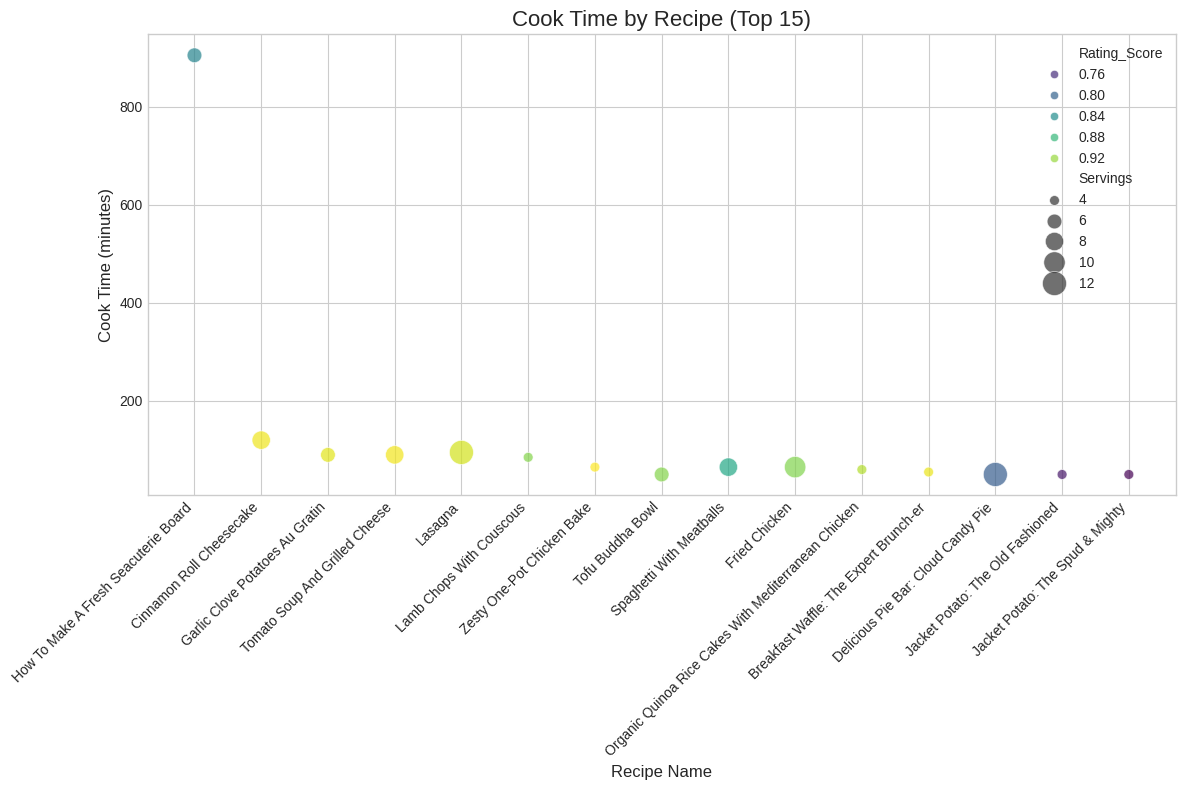

This visualization shows cook times for different recipes.
Larger circles indicate longer total prep time, and color represents rating score.


In [ ]:
print("\n INSIGHT 1: What recipes are lengthy?")

# Sort recipes by cook time for better visualization
sorted_recipes = recipe_analysis_df.sort_values('Cook_Time_(min)', ascending=False)

# Create a new figure
plt.figure(figsize=(12, 8))

# Create scatter plot using seaborn
sns.scatterplot(
    x='Recipe_Name',
    y='Total_Time_(min)',
    size='Servings',  # Size by servings
    hue='Rating_Score',       # Color by rating
    sizes=(50, 300),          # Size range
    palette='viridis',        # Color palette
    alpha=0.7,                # Transparency
    data=sorted_recipes[:15]  # Use top 15 recipes by cook time
)

# Format plot
plt.title('Cook Time by Recipe (Top 15)', fontsize=16)
plt.xlabel('Recipe Name', fontsize=12)
plt.ylabel('Cook Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.tight_layout()  # Adjust layout to prevent clipping

# Show the plot
plt.show()

print("This visualization shows cook times for different recipes.")
print("Larger circles indicate longer total prep time, and color represents rating score.")

### Question 2: Are rating and recipe complexity correlated?

#### Answer

In [ ]:
#Plot ratings against complexity metrics such as total cook time and ingredient count. We can show how the rating is correlated with both cook time and ingredient count within two plots. See prompt 14
'''
Answer: Within the code below we can see the distribution of rating versus the cook time and number of ingredients.
We can see as it relates to cook time, ratings are generally very similar for any dish under 2 hours and the rating begins to drop off the longer a recipe takes.
As it relates to ingredients and rating corelation, we can see that there really is no correlation between the number of ingredients and rating.
'''


 INSIGHT 2: Can we resonably determine if rating and complexity are related?


<ipython-input-179-cb79370643c2>:10: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

<ipython-input-179-cb79370643c2>:39: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



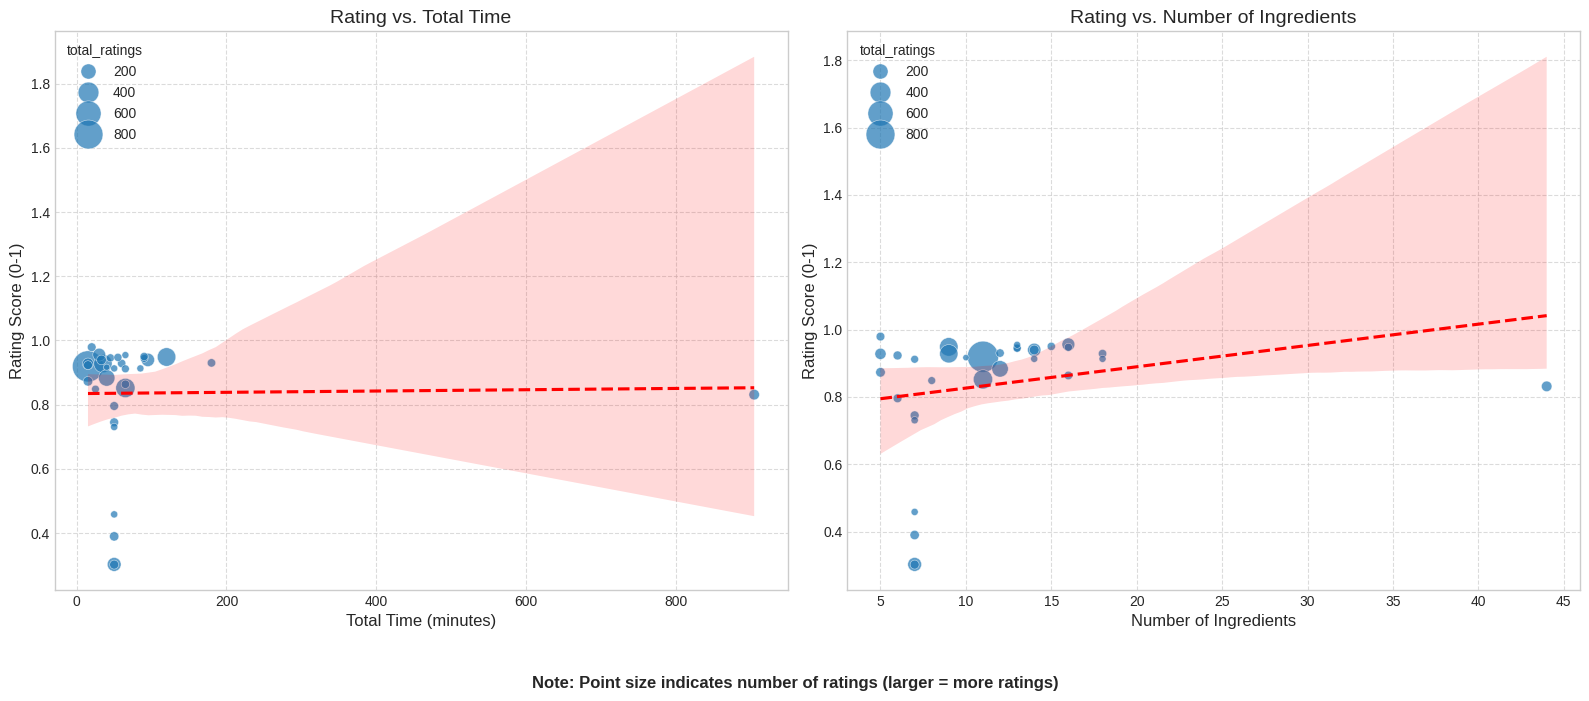

These plots show how recipe ratings correlate with complexity metrics.
The regression lines show whether more complex recipes tend to have higher or lower ratings.
Point size indicates the number of ratings, giving an idea of confidence in each data point.


In [ ]:
print("\n INSIGHT 2: Can we resonably determine if rating and complexity are related?")

# Calculate total ratings for point size
recipe_analysis_df['total_ratings'] = recipe_analysis_df['Positive_Ratings'] + recipe_analysis_df['Negative_Ratings']

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Ratings vs Cook Time
sns.scatterplot(
    x='Total_Time_(min)',
    y='Rating_Score',
    size='total_ratings',  # Size by number of ratings
    sizes=(20, 500),       # Size range
    alpha=0.7,             # Transparency
    palette='viridis',     # Color palette
    data=recipe_analysis_df,
    ax=ax1
)

# Add regression line to show trend
sns.regplot(
    x='Total_Time_(min)',
    y='Rating_Score',
    scatter=False,         # Don't plot points twice
    color='red',           # Red regression line
    line_kws={"linestyle": "--"},  # Dashed line
    data=recipe_analysis_df,
    ax=ax1
)

# Format first plot
ax1.set_title('Rating vs. Total Time', fontsize=14)
ax1.set_xlabel('Total Time (minutes)', fontsize=12)
ax1.set_ylabel('Rating Score (0-1)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Ratings vs Ingredient Count
sns.scatterplot(
    x='total_ingredients',
    y='Rating_Score',
    size='total_ratings',  # Size by number of ratings
    sizes=(20, 500),       # Size range
    alpha=0.7,             # Transparency
    palette='viridis',     # Color palette
    data=recipe_analysis_df,
    ax=ax2
)

# Add regression line to show trend
sns.regplot(
    x='total_ingredients',
    y='Rating_Score',
    scatter=False,         # Don't plot points twice
    color='red',           # Red regression line
    line_kws={"linestyle": "--"},  # Dashed line
    data=recipe_analysis_df,
    ax=ax2
)

# Format second plot
ax2.set_title('Rating vs. Number of Ingredients', fontsize=14)
ax2.set_xlabel('Number of Ingredients', fontsize=12)
ax2.set_ylabel('Rating Score (0-1)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Add a note about the visualization
plt.figtext(0.5, 0.01, 'Note: Point size indicates number of ratings (larger = more ratings)',
            ha='center', fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

print("These plots show how recipe ratings correlate with complexity metrics.")
print("The regression lines show whether more complex recipes tend to have higher or lower ratings.")
print("Point size indicates the number of ratings, giving an idea of confidence in each data point.")



### Question 3: Is there a negative or positive sentiment based on the number of ingredients and cook time?

In [ ]:
#Compare positive/negative sentiment against recipe complexity metrics such as total cook time and ingredient count. We can calculate the sentiment ratio as a ratio of positive reviews to understand the overall sentiment regarding the recipe. See prompt 14
'''
Answer: Within the code below we can see the distribution of sentiment versus the cook time and number of ingredients.
We can see as it relates to cook time, sentiment is generally very similar for any dish under 2 hours and the sentiment begins to drop off the longer a recipe takes.
As it relates to ingredients and sentiment corelation, we can see that there really is no correlation between the number of ingredients and sentiment.
'''


 INSIGHT 3: What is the sentiment for complex recipes? 


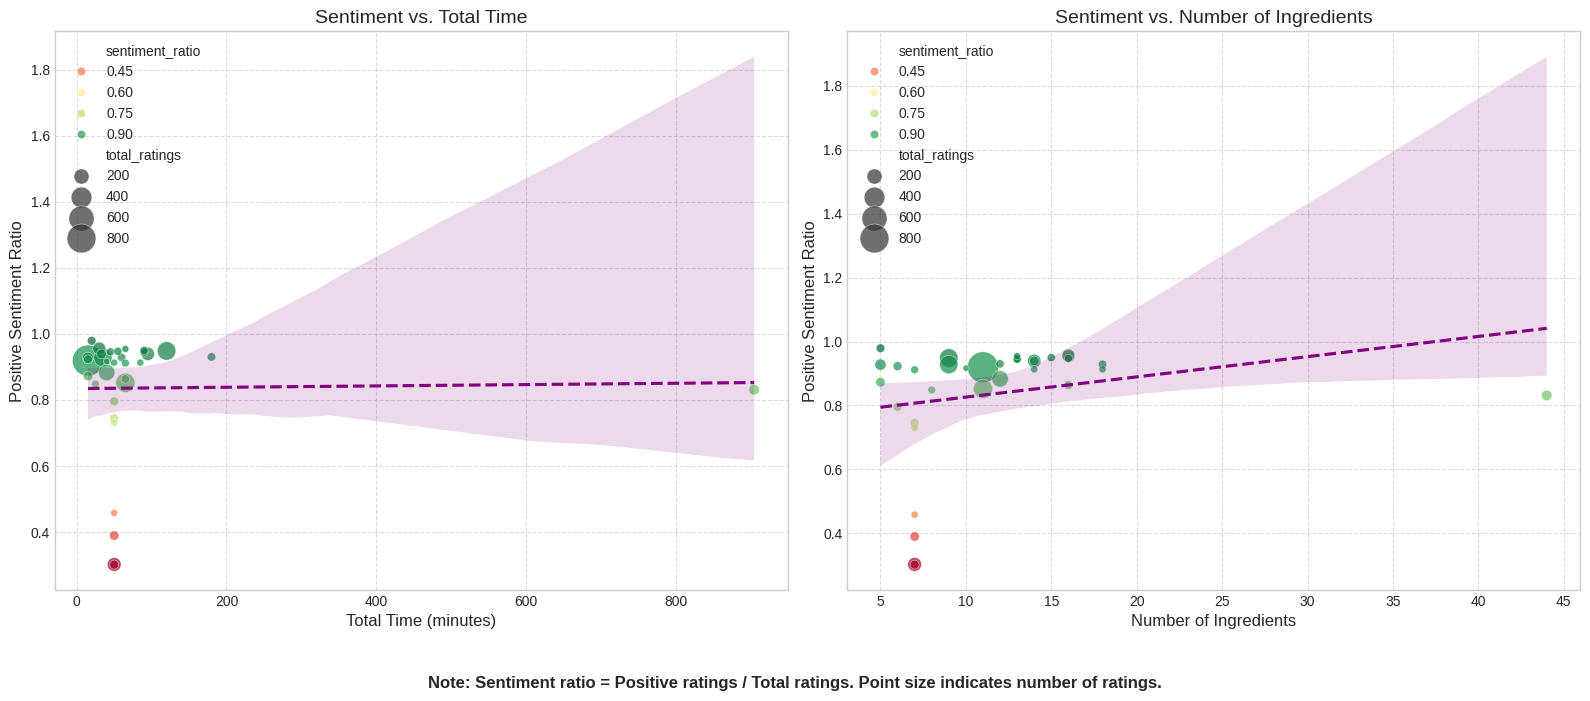

These plots show how recipe sentiment correlates with complexity metrics.
Sentiment ratio is calculated as positive ratings divided by total ratings.
The regression lines show if more complex recipes tend to have higher or lower sentiment.


In [ ]:
print("\n INSIGHT 3: What is the sentiment for complex recipes? ")

# Calculate sentiment ratio (positive ratings / total ratings)
recipe_analysis_df['sentiment_ratio'] = recipe_analysis_df['Positive_Ratings'] / (
    recipe_analysis_df['Positive_Ratings'] + recipe_analysis_df['Negative_Ratings']
)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Sentiment vs Cook Time
sns.scatterplot(
    x='Total_Time_(min)',
    y='sentiment_ratio',
    size='total_ratings',    # Size by total ratings
    sizes=(20, 500),         # Size range
    alpha=0.7,               # Transparency
    palette='RdYlGn',        # Red-Yellow-Green color map
    hue='sentiment_ratio',   # Color by sentiment
    data=recipe_analysis_df,
    ax=ax1
)

# Add regression line
sns.regplot(
    x='Total_Time_(min)',
    y='sentiment_ratio',
    scatter=False,        # Don't plot points twice
    color='purple',       # Purple regression line
    line_kws={"linestyle": "--"},  # Dashed line
    data=recipe_analysis_df,
    ax=ax1
)

# Format first plot
ax1.set_title('Sentiment vs. Total Time', fontsize=14)
ax1.set_xlabel('Total Time (minutes)', fontsize=12)
ax1.set_ylabel('Positive Sentiment Ratio', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Sentiment vs Ingredient Count
sns.scatterplot(
    x='total_ingredients',
    y='sentiment_ratio',
    size='total_ratings',    # Size by total ratings
    sizes=(20, 500),         # Size range
    alpha=0.7,               # Transparency
    palette='RdYlGn',        # Red-Yellow-Green color map
    hue='sentiment_ratio',   # Color by sentiment
    data=recipe_analysis_df,
    ax=ax2
)

# Add regression line
sns.regplot(
    x='total_ingredients',
    y='sentiment_ratio',
    scatter=False,          # Don't plot points twice
    color='purple',         # Purple regression line
    line_kws={"linestyle": "--"},  # Dashed line
    data=recipe_analysis_df,
    ax=ax2
)

# Format second plot
ax2.set_title('Sentiment vs. Number of Ingredients', fontsize=14)
ax2.set_xlabel('Number of Ingredients', fontsize=12)
ax2.set_ylabel('Positive Sentiment Ratio', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Add a note about the visualization
plt.figtext(0.5, 0.01, 'Note: Sentiment ratio = Positive ratings / Total ratings. Point size indicates number of ratings.',
            ha='center', fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

print("These plots show how recipe sentiment correlates with complexity metrics.")
print("Sentiment ratio is calculated as positive ratings divided by total ratings.")
print("The regression lines show if more complex recipes tend to have higher or lower sentiment.")


### Question 4: How popular are certain restaurant across time? I.e., Over the last 25 years

#### Answer

In [ ]:
#Create a visualization of how frequently dishes appear on menus since 2000. We will need to filter for restaurant dishes beyond 2000; see prompt 14.
'''
Answer: Within the code below we can see how popular specific restaurant dishes are. This serves as a good baseline
and insight to understand if there is some correlation between the popularity of a recipe and those popular
at restaurants - i.e. to people love ordering things they cant cook? It appears based on the data below
and limited recipe sample size that there is not an immediate correlation between popular recipes and those
dishes that appear on menus.
'''

'\nWithin the code below we can see the distribution of sentiment versus the cook time and number of ingredients.\nWe can see as it relates to cook time, sentiment is generally very similar for any dish under 2 hours and the sentiment begins to drop off the longer a recipe takes.\nAs it relates to ingredients and sentiment corelation, we can see that there really is no correlation between the number of ingredients and sentiment.\n'


 INSIGHT 4: Most popular restaurant dishes Since 2000


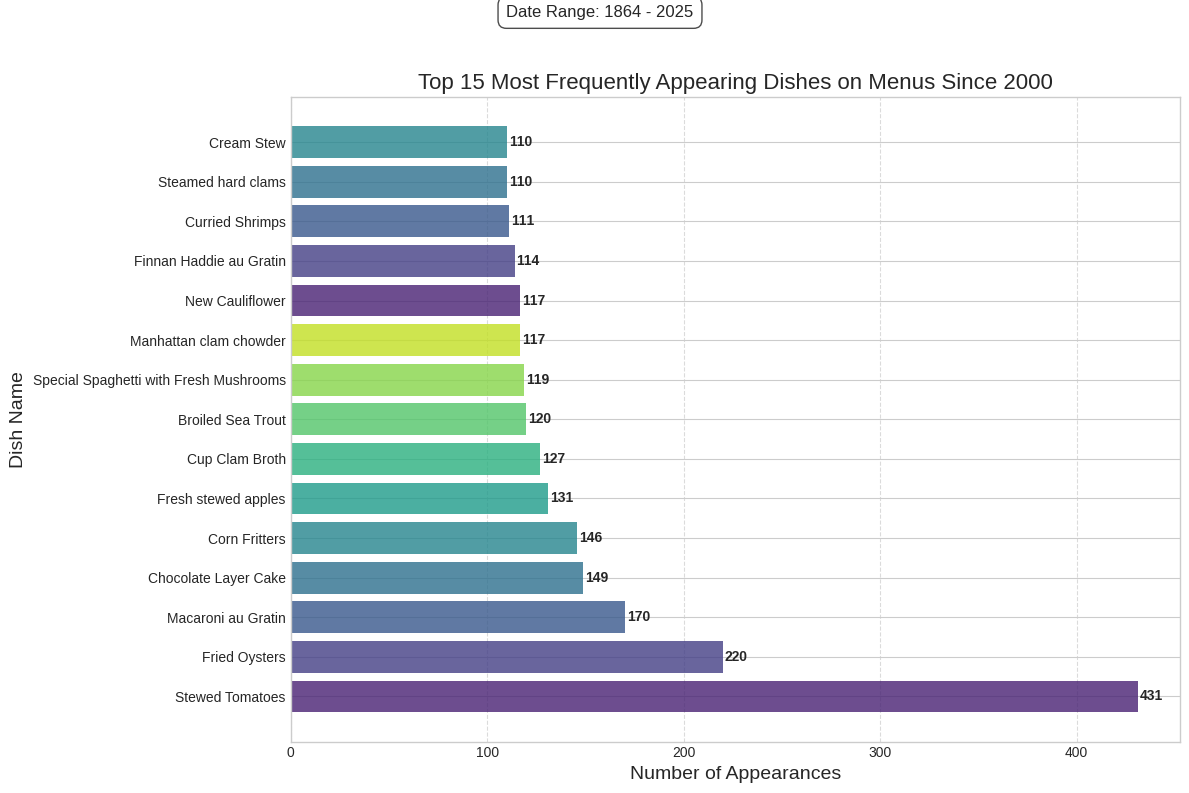

This visualization shows the most frequently appearing dishes on menus since 2000.
The date range for these dishes is from 1864 to 2025.


In [ ]:
print("\n INSIGHT 4: Most popular restaurant dishes Since 2000")

# Filter dishes that appeared from 2000 onwards
recent_dishes = dish_df_v2[dish_df_v2['last_appeared'] >= 2000].copy()

# Get top dishes by number of appearances
top_dishes = recent_dishes.sort_values(by='times_appeared', ascending=False).head(15)

# Create figure
plt.figure(figsize=(12, 8))

# Create horizontal bar chart (better for displaying dish names)
bars = plt.barh(
    top_dishes['name'],
    top_dishes['times_appeared'],
    color=sns.color_palette('viridis', 10),
    alpha=0.8
)

# Add values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontweight='bold'
    )

# Format the plot
plt.title('Top 15 Most Frequently Appearing Dishes on Menus Since 2000', fontsize=16)
plt.xlabel('Number of Appearances', fontsize=14)
plt.ylabel('Dish Name', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add an annotation with date range
min_year = int(top_dishes['first_appeared'].min())
max_year = int(top_dishes['last_appeared'].max())
plt.annotate(
    f'Date Range: {min_year} - {max_year}',
    xy=(0.5, 0.97),
    xycoords='figure fraction',
    ha='center',
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7)
)

# Adjust layout
plt.tight_layout()
plt.show()

print(f"This visualization shows the most frequently appearing dishes on menus since 2000.")
print(f"The date range for these dishes is from {min_year} to {max_year}.")

#### Answer

### Question 5: Over the last 25 years, which restaurant dishes increased most in price?

#### Answer

In [ ]:
#We will need to filter for restaurant dishes beyond 2000 and calculate the price difference and sort; see prompt 14.
'''
Answer: Within the code below we can see how much specific dishes increased over time. The correlation here appears
to be dishes that have been around longer, will see the largest price increases (natuarally) and there is
not really a direct correlation between recipes/popularity and price increases.

The 5 insights above set the stage for how the final insights will be derived and the method to do so.
'''


 INSIGHT 5: What restaurant dishes have become the most expensive since 2000?


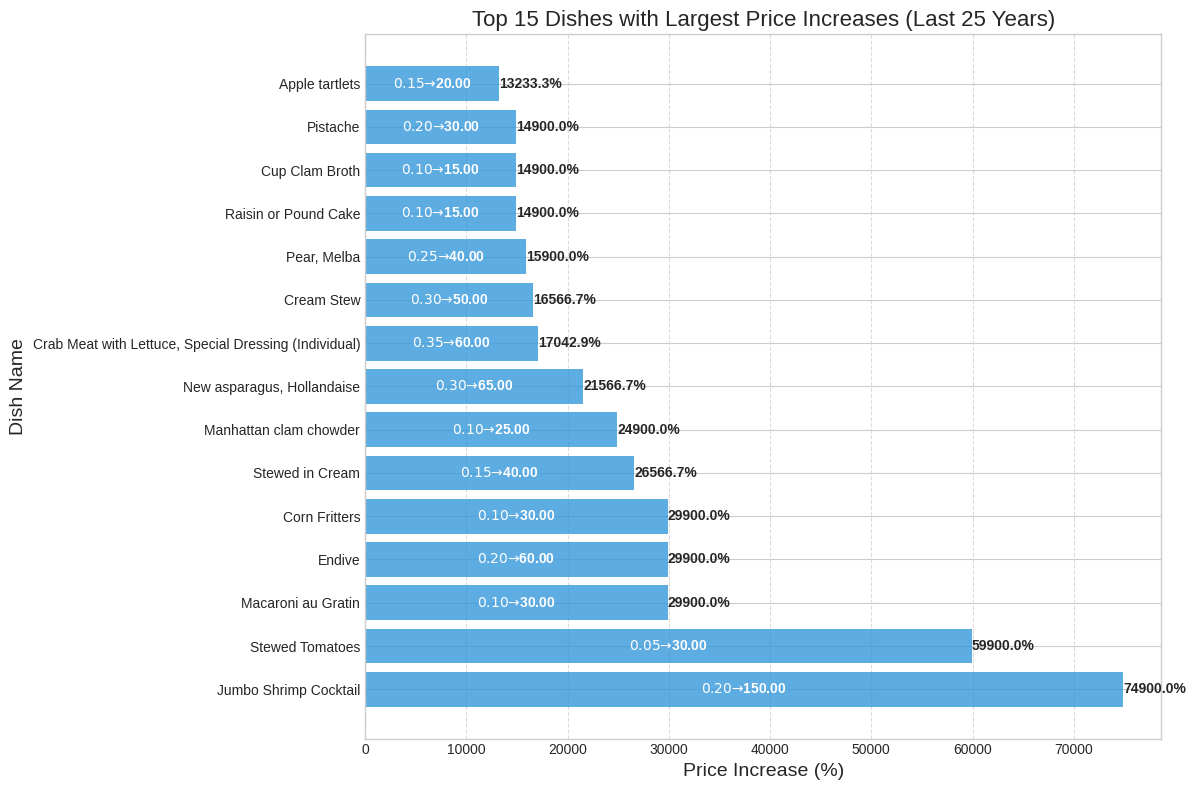

This visualization shows dishes with the largest price increases in the last 25 years.
The percentage increase is calculated from the lowest to highest recorded price for each dish.

All insights generated successfully!


In [ ]:
print("\n INSIGHT 5: What restaurant dishes have become the most expensive since 2000?")

# Get current year
current_year = datetime.now().year
years_back = 25
cutoff_year = current_year - years_back

# Filter for dishes that appeared in the last 25 years
expensive_dish_df = dish_df_v2[dish_df_v2['last_appeared'] >= cutoff_year].copy()

# Calculate price change and percentage
expensive_dish_df['price_change'] = expensive_dish_df['highest_price'] - expensive_dish_df['lowest_price']

# Add percentage change where we can calculate it (avoid division by zero)
mask = expensive_dish_df['lowest_price'] > 0
expensive_dish_df.loc[mask, 'price_change_pct'] = (
    expensive_dish_df.loc[mask, 'price_change'] / expensive_dish_df.loc[mask, 'lowest_price'] * 100
)

# Filter for dishes with valid price data
valid_price_df = expensive_dish_df[expensive_dish_df['price_change_pct'].notna()]

# Get top dishes by price increase percentage
top_increases = valid_price_df.sort_values(by='price_change_pct', ascending=False).head(15)

# Create figure
plt.figure(figsize=(12, 8))

# Create horizontal bar chart with a single color
bars = plt.barh(
    top_increases['name'],
    top_increases['price_change_pct'],
    color='#3498db',  # Consistent blue color for all bars
    alpha=0.8
)

# Add percentage values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontweight='bold'
    )

    # Add the actual price range on the bar
    low = top_increases.iloc[i]['lowest_price']
    high = top_increases.iloc[i]['highest_price']
    plt.text(
        width/2,
        bar.get_y() + bar.get_height()/2,
        f'${low:.2f} → ${high:.2f}',
        ha='center',
        va='center',
        color='white',
        fontweight='bold'
    )

# Format the plot
plt.title(f'Top 15 Dishes with Largest Price Increases (Last {years_back} Years)', fontsize=16)
plt.xlabel('Price Increase (%)', fontsize=14)
plt.ylabel('Dish Name', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

print(f"This visualization shows dishes with the largest price increases in the last {years_back} years.")
print("The percentage increase is calculated from the lowest to highest recorded price for each dish.")

print("\nAll insights generated successfully!")

##D4. Summary of key findings

Using the above to drive insights to understand the data, the final insights were derived with a focus on identifying the cost differences between eating out and cooking at home for a sample of 5 most popular recipes with a matching restaurant dish that was closely related. Please see prompts 15, 16, and 17

The final insight derived is that it is indeed significantly cheaper to cook, rather than eat out although we see from insight 1 that all of these recipes do take a substantial amount of time between prep time and cook time. So while that insight has been proved out, the next question is - is time money and are you optimizing the relationship between time and money based on time savings from eating out versus the amount of time you would spend cooking to save 34% + per serving?

In [ ]:
dish_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162136 entries, 0 to 162135
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              162136 non-null  int64  
 1   name            162131 non-null  object 
 2   menus_appeared  162136 non-null  int64  
 3   times_appeared  162136 non-null  int64  
 4   first_appeared  162136 non-null  int64  
 5   last_appeared   162136 non-null  int64  
 6   lowest_price    162136 non-null  float64
 7   highest_price   162136 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 9.9+ MB


In [ ]:
top_rated_recipes = recipe_analysis_df.sort_values('Positive_Ratings', ascending=False).head(10)
print (top_rated_recipes)

    recipe_id                           Recipe_Name  Total_Time_(min)  \
0           1                 Avocado Chicken Salad                15   
1           2              Cinnamon Roll Cheesecake               120   
4           6                Chocolate Chip Cookies                65   
2           3                     Blueberry Muffins                35   
8          11                         Layer Lasagna               450   
3           4              Tomato And Anchovy Pasta                40   
5           7                               Lasagna                95   
6           8                    Creamy Cajun Pasta                30   
23         27                Milkshake: The Tiffany                15   
9          12  How To Make A Fresh Seacuterie Board               905   

    Prep_Time_(min)  Cook_Time_(min)  Servings  Rating_Score  \
0                15                0         4      0.919355   
1                35               85         8      0.948553   
4   

In [ ]:
# Import necessary libraries; see prompts 15 - 17
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from difflib import SequenceMatcher
import textwrap

# Define a professional color palette
colors = {
    'homemade': '#1f77b4',  # Blue
    'restaurant': '#ff7f0e',  # Orange
    'savings': '#2ca02c',    # Green
    'average': '#d62728',    # Red
    'background': '#f9f9f9', # Light gray
    'text': '#333333',       # Dark gray
    'grid': '#dddddd'        # Light gray for grid
}

# Function to wrap text for better display
def wrap_text(text, width=15):
    """Wrap text to specified width using <br> for line breaks in Plotly"""
    return '<br>'.join(textwrap.wrap(text, width=width))

# Calculate cost per serving for each recipe
recipe_analysis_df['Cost_Per_Serving'] = recipe_analysis_df['Total_Recipe_Cost'] / recipe_analysis_df['Servings']

# Find the correct positive ratings column name
positive_ratings_column = None
for col in recipe_analysis_df.columns:
    if 'positive' in col.lower() and 'rating' in col.lower():
        positive_ratings_column = col
        break

if not positive_ratings_column:
    # If no column with 'positive' and 'rating' is found, check for any column with 'rating'
    for col in recipe_analysis_df.columns:
        if 'rating' in col.lower():
            positive_ratings_column = col
            break

if not positive_ratings_column:
    # Fallback to a default column name if we couldn't find the positive ratings column
    positive_ratings_column = 'Positive_Ratings'
    print(f"Warning: Could not find the positive ratings column. Using '{positive_ratings_column}' as default.")
else:
    print(f"")

# Filter dish data to include only modern dishes (1998 or later)
modern_dishes = dish_df_v2[dish_df_v2['last_appeared'] >= 1998]

# Filter out dishes with non-string names to avoid errors
modern_dishes = modern_dishes.dropna(subset=['name'])
# Ensure 'name' column contains only strings
modern_dishes['name'] = modern_dishes['name'].astype(str)

# Calculate string similarity ratio (built-in Python method)
def string_similarity(a, b):
    # Check if both inputs are strings
    if not isinstance(a, str) or not isinstance(b, str):
        return 0.0
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

# Use a reasonable threshold for finding matches
similarity_threshold = 0.65

# Create a list to store recipes with their matching dishes
matched_recipes = []
all_recipes_with_matches = []  # To store all recipes with matches for average calculation

# Check all recipes to find ones with matches
for _, recipe in recipe_analysis_df.iterrows():
    recipe_name = recipe['Recipe_Name']
    homemade_cost_per_serving = recipe['Cost_Per_Serving']
    total_homemade_cost = recipe['Total_Recipe_Cost']

    # Handle the potential missing column gracefully
    try:
        positive_ratings = recipe[positive_ratings_column]
    except:
        # If the column doesn't exist, use a default value
        positive_ratings = 0

    servings = recipe['Servings']

    # Find matching dishes with similarity >= threshold
    matching_dishes = []
    for _, dish in modern_dishes.iterrows():
        similarity = string_similarity(recipe_name, dish['name'])
        if similarity >= similarity_threshold:
            matching_dishes.append(dish)

    # Only keep recipes that have at least one matching dish
    if matching_dishes:
        avg_restaurant_price = np.mean([dish['highest_price'] for dish in matching_dishes])
        total_restaurant_cost = avg_restaurant_price * servings
        savings_per_serving = avg_restaurant_price - homemade_cost_per_serving
        total_savings = total_restaurant_cost - total_homemade_cost
        savings_percentage = (savings_per_serving / avg_restaurant_price) * 100

        # Store recipe data for possible display
        recipe_data = {
            'Recipe': recipe_name,
            'Homemade Cost Per Serving': homemade_cost_per_serving,
            'Restaurant Cost': avg_restaurant_price,
            'Matches': len(matching_dishes),
            'Positive Ratings': positive_ratings,
            'Servings': servings,
            'Total Homemade Cost': total_homemade_cost,
            'Total Restaurant Cost': total_restaurant_cost,
            'Savings Per Serving': savings_per_serving,
            'Total Savings': total_savings,
            'Savings Percentage': savings_percentage
        }

        # Add to the list of matched recipes
        matched_recipes.append(recipe_data)

        # Also add to all recipes with matches for average calculation
        all_recipes_with_matches.append(recipe_data)

# Calculate average savings across all recipes with matches
if all_recipes_with_matches:
    all_matches_df = pd.DataFrame(all_recipes_with_matches)
    avg_savings_percentage = all_matches_df['Savings Percentage'].mean()
    avg_dollar_savings = all_matches_df['Total Savings'].mean()
    avg_savings_per_serving = all_matches_df['Savings Per Serving'].mean()
    avg_homemade_cost = all_matches_df['Homemade Cost Per Serving'].mean()
    avg_restaurant_cost = all_matches_df['Restaurant Cost'].mean()
    print(f"Average savings percentage across all recipes with matches: {avg_savings_percentage:.1f}%")
    print(f"Average dollar savings, in total, across all recipes with matches: ${avg_dollar_savings:.2f}")

    # Calculate additional savings metrics
    # For per person savings based on 3 meals per day
    meals_per_day = 3
    days_per_month = 30
    days_per_year = 365

    # Calculate monthly and yearly savings per person
    monthly_savings_per_person = avg_savings_per_serving * meals_per_day * days_per_month
    yearly_savings_per_person = avg_savings_per_serving * meals_per_day * days_per_year

    # Convert matched recipes to a DataFrame
    comparison_df = pd.DataFrame(matched_recipes)

    # If we have at least one match, proceed with analysis
    if len(comparison_df) > 0:
        # Sort based on positive ratings column if it exists, otherwise sort by savings
        try:
            comparison_df = comparison_df.sort_values('Positive Ratings', ascending=False).head(5)
            print(f"Selected top 5 recipes with matching dishes, ordered by positive ratings.")
        except:
            comparison_df = comparison_df.sort_values('Savings Per Serving', ascending=False).head(5)
            print(f"Selected top 5 recipes with matching dishes, ordered by savings per serving.")

        # Add wrapped recipe names for axis labels
        comparison_df['Wrapped_Recipe'] = comparison_df['Recipe'].apply(wrap_text)

        # Add the average as a separate row
        avg_row = pd.DataFrame([{
            'Recipe': 'AVERAGE (All Recipes)',
            'Wrapped_Recipe': 'AVERAGE<br>(All Recipes)',
            'Homemade Cost Per Serving': avg_homemade_cost,
            'Restaurant Cost': avg_restaurant_cost,
            'Savings Per Serving': avg_savings_per_serving,
            'Savings Percentage': avg_savings_percentage,
            'Total Savings': avg_dollar_savings,
            'Matches': all_matches_df['Matches'].mean(),
            'Positive Ratings': all_matches_df['Positive Ratings'].mean() if 'Positive Ratings' in all_matches_df.columns else 0,
            'Servings': all_matches_df['Servings'].mean()
        }])

        # Combine regular data with average row
        plot_df = pd.concat([comparison_df, avg_row], ignore_index=True)

        # Create a more professional visualization with Plotly
        # First: Cost comparison bar chart
        fig = make_subplots(
            rows=2,
            cols=1,
            subplot_titles=(
                "Home vs Restaurant Costs",  # Simplified title for first subplot
                "Savings Percentages"        # Simplified title for second subplot
            ),
            vertical_spacing=0.3,  # Increased vertical spacing to make room for legend
            row_heights=[0.6, 0.4]
        )

        # Use wrapped recipe names for x-axis labels (first chart)
        x_labels = plot_df['Wrapped_Recipe'].tolist()

        # Create custom hover text without relying on specific columns
        hover_template_home = "<b>%{customdata}</b><br>Homemade Cost: $%{y:.2f}"
        hover_template_rest = "<b>%{customdata}</b><br>Restaurant Cost: $%{y:.2f}"

        # Add homemade cost bars
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df['Homemade Cost Per Serving'],
                name='Home Cost',  # Removed line break in legend name
                marker_color=colors['homemade'],
                text=[f"${x:.2f}" for x in plot_df['Homemade Cost Per Serving']],
                textposition='auto',
                hovertemplate=hover_template_home,
                customdata=plot_df['Recipe']  # Use full recipe name in hover
            ),
            row=1, col=1
        )

        # Add restaurant cost bars
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df['Restaurant Cost'],
                name='Restaurant Cost',  # Removed line break in legend name
                marker_color=colors['restaurant'],
                text=[f"${x:.2f}" for x in plot_df['Restaurant Cost']],
                textposition='auto',
                hovertemplate=hover_template_rest,
                customdata=plot_df['Recipe']  # Use full recipe name in hover
            ),
            row=1, col=1
        )

        # Add savings annotations
        for i, row in plot_df.iterrows():
            # Only add annotations to the first chart
            if i < len(plot_df) - 1:  # For regular recipes
                color = colors['savings']
            else:  # For average
                color = colors['average']

            fig.add_trace(
                go.Scatter(
                    x=[row['Wrapped_Recipe']],
                    y=[max(row['Homemade Cost Per Serving'], row['Restaurant Cost']) + 0.8],
                    mode='markers+text',
                    marker=dict(color=color, size=10, symbol='triangle-down'),
                    text=f"Save: ${row['Savings Per Serving']:.2f}",
                    textposition='top center',
                    hoverinfo='none',
                    showlegend=False
                ),
                row=1, col=1
            )

        # Sort by savings percentage for the second chart
        sorted_df = plot_df.sort_values('Savings Percentage', ascending=True)

        # Create wrapped labels for second chart
        y_labels = sorted_df['Wrapped_Recipe'].tolist()

        # Create simplified hover text for savings chart
        hover_template_savings = "<b>%{customdata}</b><br>Savings: %{x:.1f}%"

        # Add the savings percentage chart
        fig.add_trace(
            go.Bar(
                y=y_labels,
                x=sorted_df['Savings Percentage'],
                orientation='h',
                marker_color=[colors['savings'] if i < len(sorted_df) - 1 else colors['average']
                             for i in range(len(sorted_df))],
                text=[f"{x:.0f}%" for x in sorted_df['Savings Percentage']],
                textposition='auto',
                showlegend=False,
                hovertemplate=hover_template_savings,
                customdata=sorted_df['Recipe']  # Use full recipe name in hover
            ),
            row=2, col=1
        )

        # Add a vertical line at 0% for the second chart
        fig.add_vline(
            x=0, line_width=1, line_dash="dash", line_color="black",
            row=2, col=1
        )

        # Update layout - moving legend to the bottom
        fig.update_layout(
            title={
                'text': "Cost Comparison",  # Simplified main title
                'y': 0.98,
                'x': 0.5,
                'xanchor': 'center',
                'yanchor': 'top',
                'font': {'size': 22, 'color': colors['text']}
            },
            barmode='group',
            plot_bgcolor=colors['background'],
            paper_bgcolor=colors['background'],
            font={'color': colors['text']},
            # Move legend to bottom of the figure
            legend={
                'orientation': 'h',  # Horizontal legend
                'y': -0.15,          # Position below the plot
                'x': 0.5,            # Center horizontally
                'xanchor': 'center',
                'font': {'size': 12}
            },
            height=850,              # Slightly increased height to accommodate legend at bottom
            width=900,
            margin=dict(t=120, b=120, l=100, r=50)  # Increased bottom margin for legend
        )

        # Update subplot title position to avoid overlap with graph content
        fig.update_annotations(yshift=10)  # Move subplot titles up slightly

        # Update axes
        fig.update_xaxes(
            title_text="Recipe",
            row=1, col=1,
            title_font={'size': 14}
        )

        fig.update_yaxes(
            title_text="Cost Per Serving ($)",
            row=1, col=1,
            title_font={'size': 14}
        )

        fig.update_xaxes(
            title_text="Savings (%)",
            row=2, col=1,
            title_font={'size': 14}
        )

        # Add simplified compact annotations with recipe details
        for i, row in comparison_df.iterrows():
            recipe_info = f"{row['Servings']:.0f} servings"

            fig.add_annotation(
                x=row['Wrapped_Recipe'],
                y=-max(plot_df['Homemade Cost Per Serving'].max(),
                      plot_df['Restaurant Cost'].max()) * 0.1,  # Position below x-axis
                text=recipe_info,
                showarrow=False,
                font={'size': 10, 'color': 'gray'},
                xref="x", yref="y1"
            )

        # Add compact annotation for the average
        fig.add_annotation(
            x='AVERAGE<br>(All Recipes)',
            y=-max(plot_df['Homemade Cost Per Serving'].max(),
                  plot_df['Restaurant Cost'].max()) * 0.1,  # Position below x-axis
            text=f"{len(all_matches_df)} recipes",
            showarrow=False,
            font={'size': 10, 'color': 'gray'},
            xref="x", yref="y1"
        )

        # Add compact methodology note at the bottom
        fig.add_annotation(
            text=(f"Note: Modern dishes (1998+) with ≥{similarity_threshold*100:.0f}% name similarity. Cost per serving shown."),
            xref="paper", yref="paper",
            x=0.5, y=-0.2,  # Moved further down to avoid overlap with legend
            showarrow=False,
            font={'size': 11, 'color': 'gray'}
        )

        # Add an updated summary box with key statistics including per person savings
        summary_text = (
            f"<b>Key Findings:</b><br>" +
            f"Average Savings: ${avg_savings_per_serving:.2f} per serving<br>" +
            f"Monthly Savings Per Person: ${monthly_savings_per_person:.2f}<br>" +
            f"Annual Savings Per Person: ${yearly_savings_per_person:.2f}"
        )

        fig.add_annotation(
            x=0.97, y=0.97,
            xref="paper", yref="paper",
            text=summary_text,
            showarrow=False,
            font=dict(size=12),
            align="right",
            bordercolor="#c7c7c7",
            borderwidth=1,
            borderpad=4,
            bgcolor="white",
            opacity=0.8
        )

        # Show the figure
        fig.show()

        # Print out a summary of findings
        print("\nSummary of Findings for Top Matched Recipes:")
        print(f"Average homemade cost per serving: ${comparison_df['Homemade Cost Per Serving'].mean():.2f}")
        print(f"Average restaurant cost: ${comparison_df['Restaurant Cost'].mean():.2f}")
        print(f"Average savings per serving: ${comparison_df['Savings Per Serving'].mean():.2f}")
        print(f"Average savings percentage: {comparison_df['Savings Percentage'].mean():.1f}%")
        print(f"Average dollar savings per recipe: ${avg_dollar_savings:.2f}")

        print("\nPer Person Savings (assuming 3 meals per day, all home-cooked):")
        print(f"Average monthly savings per person: ${monthly_savings_per_person:.2f}")
        print(f"Average yearly savings per person: ${yearly_savings_per_person:.2f}")

    else:
        print("No recipes with matching dishes found.")
        print("Try reducing the similarity threshold to find more matches.")
else:
    print("No matching dishes found with the current similarity threshold.")
    print("Try reducing the similarity threshold to find more matches.")


Average savings percentage across all recipes with matches: 34.4%
Average dollar savings, in total, across all recipes with matches: $25.03
Selected top 5 recipes with matching dishes, ordered by positive ratings.



Summary of Findings for Top Matched Recipes:
Average homemade cost per serving: $5.82
Average restaurant cost: $9.15
Average savings per serving: $3.32
Average savings percentage: 34.4%
Average dollar savings per recipe: $25.03

Per Person Savings (assuming 3 meals per day, all home-cooked):
Average monthly savings per person: $299.20
Average yearly savings per person: $3640.30


##D5 Further research

There are a few things I'd like to research:


- Gather more recipe data, to combat the risk of recipes name with odd conventions (i.e. "Heavenly Delicious Mac n Cheese")
- Try to make this a little bit more location specific and find an API that returns NY specific grocery ingredient prices.
- Identify whether there is a correlation among the cultural trends on Tik-Tok (i.e., the most popular Tik-Tok videos about specific dishes) and how many times they appear on menus after the viral video...or how much the menu price has increased since the video.
- I think some more research on dish data would be helpful, specifically more timely data based the actual restaurant names as they were not provided within the dataset




## Presentation

### Introduction

**About Me:** Love for food, hence wanted my project to center around food-related data, despite potential difficulty with structure of data

**Project Goal**: Try to gain insight on a few things:
- Is there a correlation between ratings and recipe length of time?
- What is the sentiment of recipes based on the number of ingredients or cook time?
- *How much cheaper is it to cook at home versus eat out?*

### Data Description

In [ ]:
#Tasty API for recipes
tasty_df.info()
'''
Individual recipes = each row
Recipe name and ingredients = data of interest
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   recipe_id         40 non-null     int64  
 1   Recipe Name       40 non-null     object 
 2   Total Time (min)  40 non-null     int64  
 3   Prep Time (min)   40 non-null     int64  
 4   Cook Time (min)   40 non-null     int64  
 5   Servings          40 non-null     int64  
 6   Rating Score      40 non-null     float64
 7   Positive Ratings  40 non-null     int64  
 8   Negative Ratings  40 non-null     int64  
 9   Ingredients       40 non-null     object 
dtypes: float64(1), int64(7), object(2)
memory usage: 3.3+ KB


'\nIndividual recipes = each row\nRecipe name and ingredients = string and data of interest\nIngredients = data problem that needed solving\n'

In [ ]:
#Kroger API for ingredient cost
kroger_df.info()
'''
Individual product(ingredient) = each row
regular price = data of interest
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recipe_id      1363 non-null   int64  
 1   ingredient     1363 non-null   object 
 2   product_id     1363 non-null   object 
 3   description    1363 non-null   object 
 4   brand          1363 non-null   object 
 5   location_id    1363 non-null   object 
 6   regular_price  1363 non-null   float64
 7   promo_price    1363 non-null   float64
 8   size           1363 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 96.0+ KB


'\nIndividual product(ingredient) = each row\nregular price = data if interest\nlocation = problem with data set\n'

In [ ]:
#NY Public Library What's on the Menu? CSV upload
'''
Data highlights:
 - time series data
- times item appeared and highest price initial data of interest


SyntaxError: incomplete input (<ipython-input-1-f6cb346e24f4>, line 2)

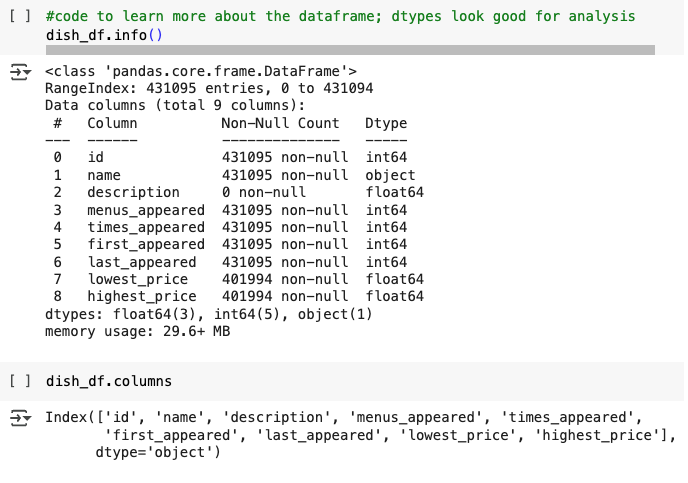

### Pre-processing Highlights

In [ ]:
#needed to parse out Ingredients data to compute cost of recipe
tasty_df['Ingredients'][0]

['⅔ cup plain Greek yogurt',
 '1 tablespoon lime juice',
 'Pepper, to taste',
 '⅛ teaspoon chili powder',
 '1 avocado, cubed, divided',
 '2 chicken breasts, cooked and shredded',
 '1 celery stalk, diced',
 '2 tablespoons diced red onion',
 'Kosher salt, to taste',
 'Low-carb bread, for serving, optional',
 'Fresh cilantro leaves, for garnish']

In [ ]:
ingredients_df.head(10)
'''
Used Chat GPT to parse out ingredients
Goal was to simplify and seperate measurements from ingredient name
'''

,recipe_id,Ingredient_1,Ingredient_2,Ingredient_3,Ingredient_4,Ingredient_5,Ingredient_6,Ingredient_7,Ingredient_8,Ingredient_9,...,Price_38,Price_39,Price_40,Price_41,Price_42,Price_43,Price_44,Measurement_2,Measurement_8,Total_Recipe_Cost
0,1,greek yogurt,lime juice,pepper,chili powder,avocado,chicken breast,celery,red onion,salt,...,None,None,None,None,None,None,None,1 tablespoon,2 tablespoons,30.031266
1,2,cream cheese,sugar,sour cream,vanilla extract,eggs,butter,brown sugar,cinnamon,cinnamon rolls,...,None,None,None,None,None,None,None,NaN,NaN,33.896533
2,3,eggs,sugar,vegetable oil,vanilla extract,flour,baking soda,baking powder,sour cream,blueberries,...,None,None,None,None,None,None,None,NaN,NaN,36.406122
3,4,butter,anchovy,bread crumbs,parmesan cheese,olive oil,garlic,red pepper flakes,cherry tomatoes,salt,...,None,None,None,None,None,None,None,NaN,NaN,61.596530
4,5,egg whites,sugar,flour,powdered sugar,vanilla extract,food coloring,buttercream,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,29.726776
5,6,pecans,coconut oil,brown sugar,sugar,non-dairy milk,vanilla extract,flour,baking soda,salt,...,None,None,None,None,None,None,None,NaN,NaN,45.093912
6,7,ricotta,mozzarella cheese,parmesan cheese,eggs,parsley,salt,olive oil,onion,ground beef,...,None,None,None,None,None,None,None,NaN,NaN,58.637590
7,8,butter,italian sausage,salt,onion,jalapeno,garlic,tomato paste,spice blend,penne pasta,...,None,None,None,None,None,None,None,NaN,NaN,40.759850
8,9,mozzarella cheese,egg yolk,pasta,NaN,NaN,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,8.361250
9,10,sweet potatoes,cooking spray,salt,maple syrup,bacon bits,marshmallow fluff,sprinkles,NaN,NaN,...,None,None,None,None,None,None,None,NaN,NaN,24.063302


### Key Findings

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from difflib import SequenceMatcher
import textwrap

# Define a professional color palette
colors = {
    'homemade': '#1f77b4',  # Blue
    'restaurant': '#ff7f0e',  # Orange
    'savings': '#2ca02c',    # Green
    'average': '#d62728',    # Red
    'background': '#f9f9f9', # Light gray
    'text': '#333333',       # Dark gray
    'grid': '#dddddd'        # Light gray for grid
}

# Function to wrap text for better display
def wrap_text(text, width=15):
    """Wrap text to specified width using <br> for line breaks in Plotly"""
    return '<br>'.join(textwrap.wrap(text, width=width))

# Calculate cost per serving for each recipe
recipe_analysis_df['Cost_Per_Serving'] = recipe_analysis_df['Total_Recipe_Cost'] / recipe_analysis_df['Servings']

# Find the correct positive ratings column name
positive_ratings_column = None
for col in recipe_analysis_df.columns:
    if 'positive' in col.lower() and 'rating' in col.lower():
        positive_ratings_column = col
        break

if not positive_ratings_column:
    # If no column with 'positive' and 'rating' is found, check for any column with 'rating'
    for col in recipe_analysis_df.columns:
        if 'rating' in col.lower():
            positive_ratings_column = col
            break

if not positive_ratings_column:
    # Fallback to a default column name if we couldn't find the positive ratings column
    positive_ratings_column = 'Positive_Ratings'
    print(f"Warning: Could not find the positive ratings column. Using '{positive_ratings_column}' as default.")
else:
    print(f"")

# Filter dish data to include only modern dishes (1998 or later)
modern_dishes = dish_df_v2[dish_df_v2['last_appeared'] >= 1998]

# Filter out dishes with non-string names to avoid errors
modern_dishes = modern_dishes.dropna(subset=['name'])
# Ensure 'name' column contains only strings
modern_dishes['name'] = modern_dishes['name'].astype(str)

# Calculate string similarity ratio (built-in Python method)
def string_similarity(a, b):
    # Check if both inputs are strings
    if not isinstance(a, str) or not isinstance(b, str):
        return 0.0
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

# Use a reasonable threshold for finding matches
similarity_threshold = 0.65

# Create a list to store recipes with their matching dishes
matched_recipes = []
all_recipes_with_matches = []  # To store all recipes with matches for average calculation

# Check all recipes to find ones with matches
for _, recipe in recipe_analysis_df.iterrows():
    recipe_name = recipe['Recipe_Name']
    homemade_cost_per_serving = recipe['Cost_Per_Serving']
    total_homemade_cost = recipe['Total_Recipe_Cost']

    # Handle the potential missing column gracefully
    try:
        positive_ratings = recipe[positive_ratings_column]
    except:
        # If the column doesn't exist, use a default value
        positive_ratings = 0

    servings = recipe['Servings']

    # Find matching dishes with similarity >= threshold
    matching_dishes = []
    for _, dish in modern_dishes.iterrows():
        similarity = string_similarity(recipe_name, dish['name'])
        if similarity >= similarity_threshold:
            matching_dishes.append(dish)

    # Only keep recipes that have at least one matching dish
    if matching_dishes:
        avg_restaurant_price = np.mean([dish['highest_price'] for dish in matching_dishes])
        total_restaurant_cost = avg_restaurant_price * servings
        savings_per_serving = avg_restaurant_price - homemade_cost_per_serving
        total_savings = total_restaurant_cost - total_homemade_cost
        savings_percentage = (savings_per_serving / avg_restaurant_price) * 100

        # Store recipe data for possible display
        recipe_data = {
            'Recipe': recipe_name,
            'Homemade Cost Per Serving': homemade_cost_per_serving,
            'Restaurant Cost': avg_restaurant_price,
            'Matches': len(matching_dishes),
            'Positive Ratings': positive_ratings,
            'Servings': servings,
            'Total Homemade Cost': total_homemade_cost,
            'Total Restaurant Cost': total_restaurant_cost,
            'Savings Per Serving': savings_per_serving,
            'Total Savings': total_savings,
            'Savings Percentage': savings_percentage
        }

        # Add to the list of matched recipes
        matched_recipes.append(recipe_data)

        # Also add to all recipes with matches for average calculation
        all_recipes_with_matches.append(recipe_data)

# Calculate average savings across all recipes with matches
if all_recipes_with_matches:
    all_matches_df = pd.DataFrame(all_recipes_with_matches)
    avg_savings_percentage = all_matches_df['Savings Percentage'].mean()
    avg_dollar_savings = all_matches_df['Total Savings'].mean()
    avg_savings_per_serving = all_matches_df['Savings Per Serving'].mean()
    avg_homemade_cost = all_matches_df['Homemade Cost Per Serving'].mean()
    avg_restaurant_cost = all_matches_df['Restaurant Cost'].mean()
    print(f"Average savings percentage across all recipes with matches: {avg_savings_percentage:.1f}%")
    print(f"Average dollar savings, in total, across all recipes with matches: ${avg_dollar_savings:.2f}")

    # Calculate additional savings metrics
    # For per person savings based on 3 meals per day
    meals_per_day = 3
    days_per_month = 30
    days_per_year = 365

    # Calculate monthly and yearly savings per person
    monthly_savings_per_person = avg_savings_per_serving * meals_per_day * days_per_month
    yearly_savings_per_person = avg_savings_per_serving * meals_per_day * days_per_year

    # Convert matched recipes to a DataFrame
    comparison_df = pd.DataFrame(matched_recipes)

    # If we have at least one match, proceed with analysis
    if len(comparison_df) > 0:
        # Sort based on positive ratings column if it exists, otherwise sort by savings
        try:
            comparison_df = comparison_df.sort_values('Positive Ratings', ascending=False).head(5)
            print(f"Selected top 5 recipes with matching dishes, ordered by positive ratings.")
        except:
            comparison_df = comparison_df.sort_values('Savings Per Serving', ascending=False).head(5)
            print(f"Selected top 5 recipes with matching dishes, ordered by savings per serving.")

        # Add wrapped recipe names for axis labels
        comparison_df['Wrapped_Recipe'] = comparison_df['Recipe'].apply(wrap_text)

        # Add the average as a separate row
        avg_row = pd.DataFrame([{
            'Recipe': 'AVERAGE (All Recipes)',
            'Wrapped_Recipe': 'AVERAGE<br>(All Recipes)',
            'Homemade Cost Per Serving': avg_homemade_cost,
            'Restaurant Cost': avg_restaurant_cost,
            'Savings Per Serving': avg_savings_per_serving,
            'Savings Percentage': avg_savings_percentage,
            'Total Savings': avg_dollar_savings,
            'Matches': all_matches_df['Matches'].mean(),
            'Positive Ratings': all_matches_df['Positive Ratings'].mean() if 'Positive Ratings' in all_matches_df.columns else 0,
            'Servings': all_matches_df['Servings'].mean()
        }])

        # Combine regular data with average row
        plot_df = pd.concat([comparison_df, avg_row], ignore_index=True)

        # Create a more professional visualization with Plotly
        # First: Cost comparison bar chart
        fig = make_subplots(
            rows=2,
            cols=1,
            subplot_titles=(
                "Home vs Restaurant Costs",  # Simplified title for first subplot
                "Savings Percentages"        # Simplified title for second subplot
            ),
            vertical_spacing=0.3,  # Increased vertical spacing to make room for legend
            row_heights=[0.6, 0.4]
        )

        # Use wrapped recipe names for x-axis labels (first chart)
        x_labels = plot_df['Wrapped_Recipe'].tolist()

        # Create custom hover text without relying on specific columns
        hover_template_home = "<b>%{customdata}</b><br>Homemade Cost: $%{y:.2f}"
        hover_template_rest = "<b>%{customdata}</b><br>Restaurant Cost: $%{y:.2f}"

        # Add homemade cost bars
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df['Homemade Cost Per Serving'],
                name='Home Cost',  # Removed line break in legend name
                marker_color=colors['homemade'],
                text=[f"${x:.2f}" for x in plot_df['Homemade Cost Per Serving']],
                textposition='auto',
                hovertemplate=hover_template_home,
                customdata=plot_df['Recipe']  # Use full recipe name in hover
            ),
            row=1, col=1
        )

        # Add restaurant cost bars
        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=plot_df['Restaurant Cost'],
                name='Restaurant Cost',  # Removed line break in legend name
                marker_color=colors['restaurant'],
                text=[f"${x:.2f}" for x in plot_df['Restaurant Cost']],
                textposition='auto',
                hovertemplate=hover_template_rest,
                customdata=plot_df['Recipe']  # Use full recipe name in hover
            ),
            row=1, col=1
        )

        # Add savings annotations
        for i, row in plot_df.iterrows():
            # Only add annotations to the first chart
            if i < len(plot_df) - 1:  # For regular recipes
                color = colors['savings']
            else:  # For average
                color = colors['average']

            fig.add_trace(
                go.Scatter(
                    x=[row['Wrapped_Recipe']],
                    y=[max(row['Homemade Cost Per Serving'], row['Restaurant Cost']) + 0.8],
                    mode='markers+text',
                    marker=dict(color=color, size=10, symbol='triangle-down'),
                    text=f"Save: ${row['Savings Per Serving']:.2f}",
                    textposition='top center',
                    hoverinfo='none',
                    showlegend=False
                ),
                row=1, col=1
            )

        # Sort by savings percentage for the second chart
        sorted_df = plot_df.sort_values('Savings Percentage', ascending=True)

        # Create wrapped labels for second chart
        y_labels = sorted_df['Wrapped_Recipe'].tolist()

        # Create simplified hover text for savings chart
        hover_template_savings = "<b>%{customdata}</b><br>Savings: %{x:.1f}%"

        # Add the savings percentage chart
        fig.add_trace(
            go.Bar(
                y=y_labels,
                x=sorted_df['Savings Percentage'],
                orientation='h',
                marker_color=[colors['savings'] if i < len(sorted_df) - 1 else colors['average']
                             for i in range(len(sorted_df))],
                text=[f"{x:.0f}%" for x in sorted_df['Savings Percentage']],
                textposition='auto',
                showlegend=False,
                hovertemplate=hover_template_savings,
                customdata=sorted_df['Recipe']  # Use full recipe name in hover
            ),
            row=2, col=1
        )

        # Add a vertical line at 0% for the second chart
        fig.add_vline(
            x=0, line_width=1, line_dash="dash", line_color="black",
            row=2, col=1
        )

        # Update layout - moving legend to the bottom
        fig.update_layout(
            title={
                'text': "Cost Comparison",  # Simplified main title
                'y': 0.98,
                'x': 0.5,
                'xanchor': 'center',
                'yanchor': 'top',
                'font': {'size': 22, 'color': colors['text']}
            },
            barmode='group',
            plot_bgcolor=colors['background'],
            paper_bgcolor=colors['background'],
            font={'color': colors['text']},
            # Move legend to bottom of the figure
            legend={
                'orientation': 'h',  # Horizontal legend
                'y': -0.15,          # Position below the plot
                'x': 0.5,            # Center horizontally
                'xanchor': 'center',
                'font': {'size': 12}
            },
            height=850,              # Slightly increased height to accommodate legend at bottom
            width=900,
            margin=dict(t=120, b=120, l=100, r=50)  # Increased bottom margin for legend
        )

        # Update subplot title position to avoid overlap with graph content
        fig.update_annotations(yshift=10)  # Move subplot titles up slightly

        # Update axes
        fig.update_xaxes(
            title_text="Recipe",
            row=1, col=1,
            title_font={'size': 14}
        )

        fig.update_yaxes(
            title_text="Cost Per Serving ($)",
            row=1, col=1,
            title_font={'size': 14}
        )

        fig.update_xaxes(
            title_text="Savings (%)",
            row=2, col=1,
            title_font={'size': 14}
        )

        # Add simplified compact annotations with recipe details
        for i, row in comparison_df.iterrows():
            recipe_info = f"{row['Servings']:.0f} servings"

            fig.add_annotation(
                x=row['Wrapped_Recipe'],
                y=-max(plot_df['Homemade Cost Per Serving'].max(),
                      plot_df['Restaurant Cost'].max()) * 0.1,  # Position below x-axis
                text=recipe_info,
                showarrow=False,
                font={'size': 10, 'color': 'gray'},
                xref="x", yref="y1"
            )

        # Add compact annotation for the average
        fig.add_annotation(
            x='AVERAGE<br>(All Recipes)',
            y=-max(plot_df['Homemade Cost Per Serving'].max(),
                  plot_df['Restaurant Cost'].max()) * 0.1,  # Position below x-axis
            text=f"{len(all_matches_df)} recipes",
            showarrow=False,
            font={'size': 10, 'color': 'gray'},
            xref="x", yref="y1"
        )

        # Add compact methodology note at the bottom
        fig.add_annotation(
            text=(f"Note: Modern dishes (1998+) with ≥{similarity_threshold*100:.0f}% name similarity. Cost per serving shown."),
            xref="paper", yref="paper",
            x=0.5, y=-0.2,  # Moved further down to avoid overlap with legend
            showarrow=False,
            font={'size': 11, 'color': 'gray'}
        )

        # Add an updated summary box with key statistics including per person savings
        summary_text = (
            f"<b>Key Findings:</b><br>" +
            f"Average Savings: ${avg_savings_per_serving:.2f} per serving<br>" +
            f"Monthly Savings Per Person: ${monthly_savings_per_person:.2f}<br>" +
            f"Annual Savings Per Person: ${yearly_savings_per_person:.2f}"
        )

        fig.add_annotation(
            x=0.97, y=0.97,
            xref="paper", yref="paper",
            text=summary_text,
            showarrow=False,
            font=dict(size=12),
            align="right",
            bordercolor="#c7c7c7",
            borderwidth=1,
            borderpad=4,
            bgcolor="white",
            opacity=0.8
        )

        # Show the figure
        fig.show()

        # Print out a summary of findings
        print("\nSummary of Findings for Top Matched Recipes:")
        print(f"Average homemade cost per serving: ${comparison_df['Homemade Cost Per Serving'].mean():.2f}")
        print(f"Average restaurant cost: ${comparison_df['Restaurant Cost'].mean():.2f}")
        print(f"Average savings per serving: ${comparison_df['Savings Per Serving'].mean():.2f}")
        print(f"Average savings percentage: {comparison_df['Savings Percentage'].mean():.1f}%")
        print(f"Average dollar savings per recipe: ${avg_dollar_savings:.2f}")

        print("\nPer Person Savings (assuming 3 meals per day, all home-cooked):")
        print(f"Average monthly savings per person: ${monthly_savings_per_person:.2f}")
        print(f"Average yearly savings per person: ${yearly_savings_per_person:.2f}")

    else:
        print("No recipes with matching dishes found.")
        print("Try reducing the similarity threshold to find more matches.")
else:
    print("No matching dishes found with the current similarity threshold.")
    print("Try reducing the similarity threshold to find more matches.")


Average savings percentage across all recipes with matches: 34.4%
Average dollar savings, in total, across all recipes with matches: $25.03
Selected top 5 recipes with matching dishes, ordered by positive ratings.



Summary of Findings for Top Matched Recipes:
Average homemade cost per serving: $5.82
Average restaurant cost: $9.15
Average savings per serving: $3.32
Average savings percentage: 34.4%
Average dollar savings per recipe: $25.03

Per Person Savings (assuming 3 meals per day, all home-cooked):
Average monthly savings per person: $299.20
Average yearly savings per person: $3640.30


## References/Work Cited

References

"what are the best libraries to use if I wanted to compare two strings of text that may be similar and then convert both of them to a single text (i.e., one API returns the string "Brown Sugar" and other returns the string "Domino Brown Sugar", I want the code to identify this similarity and change both to "Brown Sugar" so that these fields are consistent and analysis can be performed); also any other recommended visualization libraries I should use - please provide the command to pip install these external libraries" prompt. Anthropic Claude, April 18 Sonnet 3.7 version, https://claude.ai/

Prompt 2: Given I have the following insights to derive, please provide a step by step guide on how to use the Requests library for each of the following API end points. Please also help me to understand if I should append lists to pull in the required columns and save this as a variable to create dataframes resulting from these api calls or create a variable that stores the JSON results and use the pd.DataFrame() method to create the dataframes for each API and then perform data discovery to drop the columns not needed for analysis. APIs are as follows:
* https://tasty.p.rapidapi.com/recipes/list (Tasty API to get recipe data including name, total cook/prep time, ingredients, servings; https://rapidapi.com/apidojo/api/tasty/)
* https://api.kroger.com/v1/connect/oauth2/token (Kroger public API to obtain product prices; https://developer.kroger.com/reference)
* http://api.menus.nypl.org/menus (https://nypl.github.io/menus-api/.
Keep the code simple and understandable for someone that is a beginner in Python as I will need to comment this out" prompt. Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/

Prompt 3: "I want to create a data frame with the following data from the Tasty recipes/list api, I have already called the API to obtain data:
- Recipe name
- Number of servings (i.e., yield)
- Ingredients (preferably a list and measurement of all ingredients; For the ingredient raw text I want all of the ingredients and their mesurement per recipe)
- Recipe ratings
- Number of recipe ratings
- Recipe prep time
- Recipe cook time
- total_time_minutes
- user_ratings --> negatibve count, positive count, and score
- yields"
prompt. Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/


Prompt 4: "Please explain to me in detail how to connect to the public Products API for Kroger: https://developer.kroger.com/api-products/api/product-api-public. I believe I need a  API token for the public API due to OAuth2. Please help me to call the API in the most simplistic manner possible and guide me through the parameters, required credentials and variables to make the code as modular as possible" prompt. Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/

Prompt 5: "Please find the nearest ID for a Kroger store near nyc and take off the mil filter. I want every single product type" prompt.Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/

Prompt 6: "Please create a new variable called search terms which is the simplified version of each ingredient for the 40 recipes attached. Please remove the measurements and ensure that each ingredient is simple and aligns with the Kroger database/product API (for example, instead of slices of hearty white bread, please change to white bread so that the filter.term parameter can be used efficiently). Please also provide the python code to simplify the verbiage and a column that indicates the measurement (i.e, change ⅔ cup whole milk or coconut milk' in the raw data to one column labeled ingredient 1 [with whole milk] and another column labeled ingredient 1 measurement (.75 cup). I want the actual list, not the code to create it" prompt.Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/

Prompt 7: "I have a list, its called kroger_search_terms. How do I call the Kroger API to get every item within the nested list (i.e., the list is roger search terms and there is a list within the list for each recipe, totalig 40 recipes)" prompt.Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/


Prompt 8: "What if I want it to iterate through several Kroger locations to find prices for the product in my list, please prtovide the 5 locations IDs that I can use to search for a price of the ingredient. Please iterate through each location via the API parameters and ensure that we can bring in a price for each product in the recipe list (kroger_search_terms parameter)" prompt.Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/


Prompt 9: "Great. I have another dataframe that has an existing column labeled ingredients, specifically: tasty_df['Ingredients']. The format is all of the ingredients are lumped together as a string in the column with the measurements before the ingredient and then each ingredient separated by a comma. Please help me to write the code to align these ingredients with the Kroger products we imported using the kroger_search_terms and simplify the names/string values (for example, instead of finely chopped pecans, it is just pecans). Further, I'd like to create two columns for each individual ingredient (Ingredient 1 Name with the name of the shortened ingredient and Ingredient 1 Measurement that contains the measurement, if there are multiple ingredients it will create multiple columns - i.e.,, if there are 4 ingredients there will be 8 columns for this recipe --> 4 Ingredient columns and 4 measurement columns).

please write the code to reformat all of this data to align with the above. I need the code to be understandable. Keep it simple. Use existing methods and functions, do not define new ones or new classes. This needs to be as simple as humanly possible to achieve the insights" prompt.Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/


Prompt 10: "how do I drop all of the rows where the highrstprice and lowest price are null" prompt. Anthropic Claude, April 21 Sonnet 3.7 version, https://claude.ai/

Prompt 11: "I want to create an analysis dataframe named "analysis_df" with the following columns from tasty_df and ingredients_df , but I want to make sure the data aligns by ensuring that the data populated has to match the recipe  ID. Combined analysis_df to include all columns from the tasty_df(but create a copy of the tasty_df) and the following columns from the ingredients_df, enjoined by the common recipe name column/id to match the values as referenced above: * Total_Recipe_Cost * total_ingredients * avg_price_ingredient" prompt. Anthropic Claude, April 27 Sonnet 3.7 version, https://claude.ai/


Prompt 12: "For the following recipes, please find the average Prep time and Cook time and return a value total time which is the sum of prep and cook time

Cinnamon Roll Cheesecake
Tomato And Anchovy Pasta
Savory Lasagna
Creamy Cajun Pasta
Jazzy Shrimp And Grits
Organic Quinoa Rice Cakes With Mediterranean Chicken
Savoury Spaghetti With Meatballs
Jazzy Fried Chicken
Instant Energy Ginger Citrus Spritz
Zesty One-Pot Chicken Bake
Hearty Lamb Chops With Couscous
Milkshake: The Tiffany
Milkshake: The Caramel Alon
Relaxation Chamomile Lavender Hot Toddy
Fiery Chicken Wings
Savoury White Fish With Simmered Tomatoes
Delicious Pie Bar: Cloud Candy Pie
Roasted Tomato Soup And Grilled Cheese
Breakfast Waffle: The Expert Brunch-er

pleaase search the internet, if you find multipel recipes please average them." prompt. Anthropic Claude, April 27 Sonnet 3.7 version, https://claude.ai/

Prompt 13: "Now please review the two dataframes (recipe_analysis_df attached as aggregage_data.xlsx excel  and dish_df_v2 attached as dish_data excel) and let me know of any of the following pre-processing required to cleanse and format the data such as below: * Remove spaces and special characters; replace spaces with "_" in column names. * Format numeric values with $ for price and cost and other numeric values with thousand seperators.
Please write the code for the above in the most simple way possible, I do not want custom functions or classes, use the libraries already available as identified." prompt. Anthropic Claude, April 27 Sonnet 3.7 version, https://claude.ai/

Prompt 14: "I have two dataframes with recipe and restaurant data. I want the following insights to be derived, but please ensure the code is as simple and modular as possible, someone with no coding experience should be able to follow what is happening within the code. This needs to follow engineering and software best practices, but please do not create custom classes. Use libraries, methods and functions already available within libraries such as Pandas, seaborn, matplotlib
Insights to be derived from data:
1. Create a scatter plot of total cook times, by recipe name --> recipe_analysis_df
2. Plot ratings against complexity metrics such as total cook time and ingredient count (if possible please use Google's Natural Language API) --> recipe_analysis_df
3. Compare positive/negative sentiment against recipe complexity metrics such as total cook time and ingredient count (if possible please use Google's Natural Language API) --> recipe_analysis_df  
4. Create a visualization of how frequently dishes appear on menus since 2000 --> dish_df
5. Create a visual representation showing over the last 25 years, which restaurant dishes increased most in price? --> dish_df
Please also comment out for each insight how you would derive the insight, including packages and APIs used, rationale for why this is the most modular and streamlined way to derive this insight." prompt. Anthropic Claude, April 27 Sonnet 3.7 version, https://claude.ai/

Prompt 15: "I have two data frames (see attached, one data frame dish_df_v2 attached as dish_data_to_read.xlsx and recipe_analysis_df attached as aggregage_data_to_read.xlsx). What I want to do is compare each dishes total price in the recipe_analysis_df (Total_Recipe_Cost as total cost and recipe_name as the string text to compare) to the most similar dish in the dish_df_v2 cost (for dishes that are a match it will be determined by matching the recipe_name value to each name value in the dish_df_v2 data frame for those string texts that are 75% match or greater, average out the highest_price column data for all matches). I want you to determine a match by finding all string text in the dish_df_v2 that is an 75% match, using the name column, to each recipe_name in the recipe_analysis_df. The purpose is to compare how much it costs to prepare the meal versus buying it at a restaurant. I then want you to use matplotlib to prepare a chart that shows each recipe in the recipe_analysis_df and compare the cost of cooking it (within the aggregage_data_to_read.xlsx, column Total_Recipe_Cost) with the cost of getting it at a restaurant(within the dish_data_to_read.xlsx, average of highest_price column for all dishes that are an 75% or greater string match to the recipe_name). Please be creative and intuitive, making the chart easy to read and easily demonstrates the difference in eating out versus cooking at home.

I do NOT want classes and custom functions, I do not want classes and custom functions. I want to use methods already available and significantly streamline the code, it should not be complex. Someone with very little Python experience should be able to unbderstand what is happening in the code." prompt. Anthropic Claude, May 4 Sonnet 3.7 version, https://claude.ai/

Prompt 16: "for the above code, please amend so that only top 5 with a matching dish and then include a data point that is the average total savings among all recipes by both percentage and dollar value" prompt. Anthropic Claude, May 4 Sonnet 3.7 version, https://claude.ai/

Prompt 17: "for the code below, please make it more aesthetically appealing and professional whether you use plotly or another library and make sure the legends are not too long and the visual output/text does not bleed into one another. The text needs to be wrapped or shortened accordinly" prompt. Anthropic Claude, May 5 Sonnet 3.7 version, https://claude.ai/